# 05 — FEM–DEM Link for Dike Assessment

This notebook connects the previously completed DEM simulations with the uploaded FEM dike assignment.

The workflow has two parts.

## Part 1 — Assignment versus DEM comparison

The assignment describes a PLAXIS finite-element model of a layered canal dike under static and dynamic loading. The available report contains:

- dike geometry and soil layering;
- constitutive models and material parameters;
- static construction and safety phases;
- dynamic boundary conditions and earthquake loading;
- settlement, lateral displacement and factor-of-safety results;
- excess pore-pressure results;
- selected effective-stress values;
- cyclic shear modulus and damping data.

The DEM model represents a much smaller direct-shear specimen. It provides:

- reference vertical stress;
- shear stress–strain response;
- peak and final shear resistance;
- peak and final stress ratios;
- DEM-derived peak and final friction angles;
- pore-pressure-dependent resistance from Notebook 04.

The FEM and DEM models do not represent identical geometry, materials, loading paths or boundary conditions. The FEM model also uses nonzero cohesion for several soil layers, while the DEM pore-pressure interpretation assumes zero effective cohesion.

Therefore, the comparison in this notebook is treated as a **partial consistency check**, not as full validation.

The comparison focuses on quantities that are sufficiently related:

- total stress;
- pore pressure;
- effective stress;
- friction angle;
- stress level;
- shear resistance;
- stress ratio;
- shear strain range.

Absolute differences and relative differences are calculated where meaningful.

## Part 2 — One-way FEM-to-DEM link

FEM-scale total stress and pore pressure are used as inputs to the DEM-derived strength relationships.

Effective vertical stress is calculated as

$$
\sigma'_v = \sigma_v - u
$$

and the pore-pressure ratio is

$$
r_u = \frac{u}{\sigma_v}
$$

The DEM-derived peak and final shear resistances are calculated from

$$
\tau_{\mathrm{peak}}
=
\sigma'_v \tan \phi'_{\mathrm{peak}}
$$

and

$$
\tau_{\mathrm{final}}
=
\sigma'_v \tan \phi'_{\mathrm{final}}
$$

This provides a simple one-way link in which continuum-scale FEM stresses are translated into local DEM-informed shear resistance.

The workflow does not transfer deformation, particle rearrangement or damage back into the FEM model. It is therefore a one-way strength-mapping demonstration rather than a fully coupled FEM–DEM simulation.

### Why the FEM and DEM geometries are different

The FEM and DEM models represent different spatial scales and serve different purposes.

The PLAXIS FEM model represents the complete dike and foundation as continuous soil domains. Its geometry is therefore defined by the actual dike profile, soil layers, groundwater conditions, loading stages and boundary conditions.

The DEM model represents a small laboratory-scale particle assembly used to study the relationship between effective vertical stress and shear resistance. Its rectangular geometry was selected to provide a controlled numerical direct-shear specimen rather than to reproduce the complete dike.

Using the same geometry would require a dike-scale particle model with substantially more particles, calibrated soil grading, spatially varying materials, hydraulic coupling and equivalent construction and loading stages. Such a model is outside the scope of this foundational demonstration.

Consequently, the comparison in this notebook is not a direct geometry-to-geometry validation. It is a one-way multiscale link in which stresses and pore pressure obtained from the FEM model are interpreted using the effective-stress-dependent resistance measured in the DEM specimen.


In [1]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# Locate the project root
# ------------------------------------------------------------

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory


# ------------------------------------------------------------
# Define input and output paths
# ------------------------------------------------------------

shear_results_path = (
    project_root
    / "results"
    / "shear"
    / "dem_shear_results.npz"
)

pore_pressure_results_path = (
    project_root
    / "results"
    / "pore_pressure"
    / "pore_pressure_sensitivity_results.npz"
)

fem_dem_results_directory = (
    project_root
    / "results"
    / "fem_dem"
)

fem_dem_results_directory.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Check that the required DEM files are available
# ------------------------------------------------------------

required_files = {
    "Notebook 03 shear results": shear_results_path,
    "Notebook 04 pore-pressure results": pore_pressure_results_path,
}

missing_files = []

for description, file_path in required_files.items():
    if file_path.exists():
        print(f"FOUND  | {description}")
        print(f"       | {file_path}")
    else:
        print(f"MISSING| {description}")
        print(f"       | {file_path}")
        missing_files.append(file_path)


if missing_files:
    missing_text = "\n".join(
        str(file_path)
        for file_path in missing_files
    )

    raise FileNotFoundError(
        "Notebook 05 cannot continue because the following "
        f"required files were not found:\n\n{missing_text}\n\n"
        "Run Notebooks 03 and 04 first, or check the project folder structure."
    )


print("\nPROJECT PATH CHECK")
print("=" * 72)
print(f"Project root               : {project_root}")
print(f"Notebook 05 output folder  : {fem_dem_results_directory}")
print("Status                     : REQUIRED FILES FOUND")

FOUND  | Notebook 03 shear results
       | C:\Users\duaas\dike_fem_dem_project\results\shear\dem_shear_results.npz
FOUND  | Notebook 04 pore-pressure results
       | C:\Users\duaas\dike_fem_dem_project\results\pore_pressure\pore_pressure_sensitivity_results.npz

PROJECT PATH CHECK
Project root               : C:\Users\duaas\dike_fem_dem_project
Notebook 05 output folder  : C:\Users\duaas\dike_fem_dem_project\results\fem_dem
Status                     : REQUIRED FILES FOUND


In [2]:
# ============================================================
# 2. LOAD AND INSPECT NOTEBOOK 03 AND NOTEBOOK 04 RESULTS
# ============================================================

shear_data = np.load(
    shear_results_path,
    allow_pickle=True,
)

pore_pressure_data = np.load(
    pore_pressure_results_path,
    allow_pickle=True,
)


# ------------------------------------------------------------
# Display all saved variable names
# ------------------------------------------------------------

print("NOTEBOOK 03 SAVED VARIABLES")
print("=" * 72)

for key in shear_data.files:
    value = shear_data[key]

    if np.ndim(value) == 0:
        print(f"{key:<40} scalar")
    else:
        print(f"{key:<40} shape = {value.shape}")


print("\nNOTEBOOK 04 SAVED VARIABLES")
print("=" * 72)

for key in pore_pressure_data.files:
    value = pore_pressure_data[key]

    if np.ndim(value) == 0:
        print(f"{key:<40} scalar")
    else:
        print(f"{key:<40} shape = {value.shape}")


# ------------------------------------------------------------
# Helper function for printing scalar values
# ------------------------------------------------------------

def print_scalar_values(dataset, dataset_name):
    """
    Print scalar values stored inside an NPZ file.

    Arrays containing one value are also treated as scalars.
    """

    print(f"\n{dataset_name} SCALAR VALUES")
    print("=" * 72)

    scalar_count = 0

    for key in dataset.files:
        value = dataset[key]

        if np.size(value) == 1:
            scalar_value = np.asarray(value).reshape(-1)[0]

            if isinstance(scalar_value, (np.floating, float)):
                print(f"{key:<40} {float(scalar_value):.8g}")

            elif isinstance(scalar_value, (np.integer, int)):
                print(f"{key:<40} {int(scalar_value)}")

            else:
                print(f"{key:<40} {scalar_value}")

            scalar_count += 1

    if scalar_count == 0:
        print("No scalar values were found.")


print_scalar_values(
    shear_data,
    "NOTEBOOK 03",
)

print_scalar_values(
    pore_pressure_data,
    "NOTEBOOK 04",
)


print("\nLOAD STATUS")
print("=" * 72)
print("Notebook 03 shear file         : LOADED")
print("Notebook 04 pore-pressure file : LOADED")
print("Next step                      : identify the exact result keys")

NOTEBOOK 03 SAVED VARIABLES
step                                     shape = (3417,)
time                                     shape = (3417,)
shear_strain                             shape = (3417,)
shear_stress                             shape = (3417,)
vertical_stress                          shape = (3417,)
filtered_vertical_stress                 shape = (3417,)
vertical_stress_error                    shape = (3417,)
stress_ratio                             shape = (3417,)
particle_contacts                        shape = (3417,)
wall_contacts                            shape = (3417,)
sliding_contacts                         shape = (3417,)
sliding_fraction                         shape = (3417,)
coordination_number                      shape = (3417,)
kinetic_energy                           shape = (3417,)
maximum_velocity                         shape = (3417,)
maximum_overlap                          shape = (3417,)
relative_maximum_overlap                 shape = (3417,)
mea

In [3]:
# ============================================================
# 3. EXTRACT ACCEPTED DEM REFERENCE VALUES
# ============================================================

def read_scalar(dataset, key):
    """
    Read one scalar value from an NPZ dataset.
    """

    if key not in dataset.files:
        raise KeyError(
            f"Required key '{key}' was not found in the saved dataset."
        )

    value = np.asarray(dataset[key])

    if value.size != 1:
        raise ValueError(
            f"Key '{key}' is not scalar. "
            f"Stored shape: {value.shape}"
        )

    return value.reshape(-1)[0]


# ------------------------------------------------------------
# Notebook 03 accepted values
# Saved stresses are in Pa, so convert them to kPa.
# ------------------------------------------------------------

dem_target_vertical_stress_kpa = (
    float(
        read_scalar(
            shear_data,
            "shear_target_vertical_stress",
        )
    )
    / 1000.0
)

dem_peak_shear_stress_kpa = (
    float(
        read_scalar(
            shear_data,
            "peak_shear_stress",
        )
    )
    / 1000.0
)

dem_final_shear_stress_kpa = (
    float(
        read_scalar(
            shear_data,
            "final_shear_stress",
        )
    )
    / 1000.0
)

dem_peak_shear_strain = float(
    read_scalar(
        shear_data,
        "peak_shear_strain",
    )
)

dem_final_shear_strain = float(
    read_scalar(
        shear_data,
        "final_shear_strain",
    )
)

dem_peak_stress_ratio = float(
    read_scalar(
        shear_data,
        "peak_stress_ratio",
    )
)

dem_final_stress_ratio = float(
    read_scalar(
        shear_data,
        "final_stress_ratio",
    )
)

notebook_03_accepted = bool(
    read_scalar(
        shear_data,
        "run_accepted",
    )
)


# ------------------------------------------------------------
# Notebook 04 accepted values
# ------------------------------------------------------------

dem_peak_friction_angle_deg = float(
    read_scalar(
        pore_pressure_data,
        "peak_friction_angle_deg",
    )
)

dem_final_friction_angle_deg = float(
    read_scalar(
        pore_pressure_data,
        "final_friction_angle_deg",
    )
)

dem_effective_cohesion_kpa = (
    float(
        read_scalar(
            pore_pressure_data,
            "effective_cohesion",
        )
    )
    / 1000.0
)

notebook_04_reference_vertical_stress_kpa = (
    float(
        read_scalar(
            pore_pressure_data,
            "reference_total_vertical_stress",
        )
    )
    / 1000.0
)

notebook_04_reference_peak_stress_kpa = (
    float(
        read_scalar(
            pore_pressure_data,
            "reference_peak_shear_stress",
        )
    )
    / 1000.0
)

notebook_04_reference_final_stress_kpa = (
    float(
        read_scalar(
            pore_pressure_data,
            "reference_final_shear_stress",
        )
    )
    / 1000.0
)

notebook_03_accepted_in_notebook_04 = bool(
    read_scalar(
        pore_pressure_data,
        "notebook_03_run_accepted",
    )
)


# ------------------------------------------------------------
# Consistency checks between Notebook 03 and Notebook 04
# ------------------------------------------------------------

stress_tolerance_kpa = 1.0e-8

vertical_stress_consistent = np.isclose(
    dem_target_vertical_stress_kpa,
    notebook_04_reference_vertical_stress_kpa,
    atol=stress_tolerance_kpa,
    rtol=0.0,
)

peak_stress_consistent = np.isclose(
    dem_peak_shear_stress_kpa,
    notebook_04_reference_peak_stress_kpa,
    atol=stress_tolerance_kpa,
    rtol=0.0,
)

final_stress_consistent = np.isclose(
    dem_final_shear_stress_kpa,
    notebook_04_reference_final_stress_kpa,
    atol=stress_tolerance_kpa,
    rtol=0.0,
)

all_reference_values_consistent = all(
    [
        vertical_stress_consistent,
        peak_stress_consistent,
        final_stress_consistent,
    ]
)


if not notebook_03_accepted:
    raise RuntimeError(
        "Notebook 03 shear run was not accepted."
    )

if not notebook_03_accepted_in_notebook_04:
    raise RuntimeError(
        "Notebook 04 does not confirm acceptance of Notebook 03."
    )

if not all_reference_values_consistent:
    raise RuntimeError(
        "Notebook 03 and Notebook 04 reference values are inconsistent."
    )


# ------------------------------------------------------------
# Print accepted reference values
# ------------------------------------------------------------

print("ACCEPTED DEM REFERENCE VALUES")
print("=" * 76)

print(
    f"Target vertical stress          : "
    f"{dem_target_vertical_stress_kpa:.4f} kPa"
)

print(
    f"Peak shear stress               : "
    f"{dem_peak_shear_stress_kpa:.4f} kPa"
)

print(
    f"Final shear stress              : "
    f"{dem_final_shear_stress_kpa:.4f} kPa"
)

print(
    f"Peak shear strain               : "
    f"{dem_peak_shear_strain:.6f}"
)

print(
    f"Final shear strain              : "
    f"{dem_final_shear_strain:.6f}"
)

print(
    f"Peak stress ratio               : "
    f"{dem_peak_stress_ratio:.6f}"
)

print(
    f"Final stress ratio              : "
    f"{dem_final_stress_ratio:.6f}"
)

print(
    f"Peak friction angle             : "
    f"{dem_peak_friction_angle_deg:.3f} degrees"
)

print(
    f"Final friction angle            : "
    f"{dem_final_friction_angle_deg:.3f} degrees"
)

print(
    f"Effective cohesion assumption   : "
    f"{dem_effective_cohesion_kpa:.4f} kPa"
)


print("\nREFERENCE FILE CONSISTENCY")
print("=" * 76)

print(
    f"Notebook 03 run accepted        : "
    f"{notebook_03_accepted}"
)

print(
    f"Notebook 04 confirms Notebook 03: "
    f"{notebook_03_accepted_in_notebook_04}"
)

print(
    f"Vertical stress values match    : "
    f"{vertical_stress_consistent}"
)

print(
    f"Peak shear values match         : "
    f"{peak_stress_consistent}"
)

print(
    f"Final shear values match        : "
    f"{final_stress_consistent}"
)

print(
    f"Overall reference consistency   : "
    f"{all_reference_values_consistent}"
)

ACCEPTED DEM REFERENCE VALUES
Target vertical stress          : 33.4271 kPa
Peak shear stress               : 13.9385 kPa
Final shear stress              : 7.7342 kPa
Peak shear strain               : 0.033053
Final shear strain              : 0.080020
Peak stress ratio               : 0.415233
Final stress ratio              : 0.245689
Peak friction angle             : 22.635 degrees
Final friction angle            : 13.804 degrees
Effective cohesion assumption   : 0.0000 kPa

REFERENCE FILE CONSISTENCY
Notebook 03 run accepted        : True
Notebook 04 confirms Notebook 03: True
Vertical stress values match    : True
Peak shear values match         : True
Final shear values match        : True
Overall reference consistency   : True


In [4]:
# ============================================================
# 4. RECORD RELEVANT FEM ASSIGNMENT INFORMATION
# ============================================================

# The uploaded assignment is a report only.
# No PLAXIS project file or exported stress-point history is available.
#
# Therefore, the FEM values below are entered manually from the report.
# They will be used only for a partial consistency check and for the
# one-way FEM-to-DEM demonstration.


# ------------------------------------------------------------
# General FEM model information
# ------------------------------------------------------------

fem_software = "PLAXIS"
fem_model_scale = "Full dike cross-section"
fem_domain_width_m = 90.0
fem_domain_depth_m = 22.3

fem_static_model_description = (
    "Static staged-construction and strength-reduction analysis"
)

fem_dynamic_model_description = (
    "Dynamic dike response using HS-small materials, "
    "free-field boundaries and a compliant base"
)


# ------------------------------------------------------------
# Static FEM results from the original model
# ------------------------------------------------------------

fem_static_maximum_settlement_m = 0.5028
fem_static_maximum_lateral_displacement_m = 0.090
fem_static_factor_of_safety = 3.2


# ------------------------------------------------------------
# Dynamic FEM results from the original model
# ------------------------------------------------------------

fem_dynamic_settlement_m = 8.18e-4
fem_dynamic_lateral_displacement_m = -1.23e-3
fem_dynamic_maximum_excess_pore_pressure_kpa = 17.13


# ------------------------------------------------------------
# Representative effective principal stresses reported for
# the five soil layers in the dynamic-analysis calculations
# ------------------------------------------------------------

fem_effective_principal_stress_kpa = {
    "Top clay": 35.28,
    "Sand": 53.80,
    "Silty clay": 61.24,
    "Sandy clay": 78.20,
    "Lower clay": 146.31,
}


# ------------------------------------------------------------
# Effective-strength parameters used in the assignment
# ------------------------------------------------------------

fem_material_parameters = pd.DataFrame(
    {
        "Material": [
            "Top clay",
            "Sand",
            "Silty clay",
            "Sandy clay",
            "Lower clay",
        ],
        "Static friction angle (deg)": [
            17.5,
            36.8625,
            17.5,
            27.5,
            17.5,
        ],
        "Dynamic friction angle (deg)": [
            20.0,
            36.9,
            17.5,
            27.5,
            17.5,
        ],
        "Effective cohesion (kPa)": [
            5.0,
            0.0,
            5.0,
            2.5,
            13.0,
        ],
        "Representative effective stress (kPa)": [
            fem_effective_principal_stress_kpa["Top clay"],
            fem_effective_principal_stress_kpa["Sand"],
            fem_effective_principal_stress_kpa["Silty clay"],
            fem_effective_principal_stress_kpa["Sandy clay"],
            fem_effective_principal_stress_kpa["Lower clay"],
        ],
    }
)


# ------------------------------------------------------------
# Cyclic torsional shear strain range from the assignment
#
# The report gives maximum strain in percent.
# Convert percent to decimal strain for comparison with DEM.
# ------------------------------------------------------------

fem_cyclic_minimum_shear_strain_percent = 0.000575
fem_cyclic_maximum_shear_strain_percent = 0.301995

fem_cyclic_minimum_shear_strain = (
    fem_cyclic_minimum_shear_strain_percent / 100.0
)

fem_cyclic_maximum_shear_strain = (
    fem_cyclic_maximum_shear_strain_percent / 100.0
)


# ------------------------------------------------------------
# Comparison classification
# ------------------------------------------------------------

comparison_classification = (
    "Partial consistency check with a one-way FEM-to-DEM demonstration"
)

full_validation_allowed = False


# ------------------------------------------------------------
# Print assignment information
# ------------------------------------------------------------

print("RECORDED FEM ASSIGNMENT INFORMATION")
print("=" * 80)

print(f"Software                         : {fem_software}")
print(f"Model scale                      : {fem_model_scale}")
print(f"Domain width                     : {fem_domain_width_m:.1f} m")
print(f"Domain depth                     : {fem_domain_depth_m:.1f} m")

print(
    f"Static maximum settlement        : "
    f"{fem_static_maximum_settlement_m:.4f} m"
)

print(
    f"Static maximum lateral movement  : "
    f"{fem_static_maximum_lateral_displacement_m:.4f} m"
)

print(
    f"Static factor of safety          : "
    f"{fem_static_factor_of_safety:.2f}"
)

print(
    f"Dynamic settlement               : "
    f"{fem_dynamic_settlement_m:.6e} m"
)

print(
    f"Dynamic lateral movement         : "
    f"{fem_dynamic_lateral_displacement_m:.6e} m"
)

print(
    f"Maximum excess pore pressure     : "
    f"{fem_dynamic_maximum_excess_pore_pressure_kpa:.2f} kPa"
)

print(
    f"Cyclic shear strain range        : "
    f"{fem_cyclic_minimum_shear_strain:.8f} "
    f"to {fem_cyclic_maximum_shear_strain:.8f}"
)

print(
    f"Comparison classification        : "
    f"{comparison_classification}"
)

print(
    f"Full validation permitted        : "
    f"{full_validation_allowed}"
)


print("\nFEM MATERIAL PARAMETERS")
print("=" * 80)

print(
    fem_material_parameters.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

RECORDED FEM ASSIGNMENT INFORMATION
Software                         : PLAXIS
Model scale                      : Full dike cross-section
Domain width                     : 90.0 m
Domain depth                     : 22.3 m
Static maximum settlement        : 0.5028 m
Static maximum lateral movement  : 0.0900 m
Static factor of safety          : 3.20
Dynamic settlement               : 8.180000e-04 m
Dynamic lateral movement         : -1.230000e-03 m
Maximum excess pore pressure     : 17.13 kPa
Cyclic shear strain range        : 0.00000575 to 0.00301995
Comparison classification        : Partial consistency check with a one-way FEM-to-DEM demonstration
Full validation permitted        : False

FEM MATERIAL PARAMETERS
  Material  Static friction angle (deg)  Dynamic friction angle (deg)  Effective cohesion (kPa)  Representative effective stress (kPa)
  Top clay                      17.5000                       20.0000                    5.0000                                35.2800
      Sa

In [5]:
# ============================================================
# 5. BUILD THE DEM–FEM COMPARABILITY TABLE
# ============================================================

comparison_rows = [
    {
        "Quantity": "Reference vertical stress",
        "DEM value": dem_target_vertical_stress_kpa,
        "FEM value": fem_effective_principal_stress_kpa["Top clay"],
        "Unit": "kPa",
        "Comparison level": "Partial",
        "Reason": (
            "Stress magnitudes are similar, but DEM normal stress and "
            "FEM principal effective stress are not identical components."
        ),
    },
    {
        "Quantity": "Peak friction angle",
        "DEM value": dem_peak_friction_angle_deg,
        "FEM value": 20.0,
        "Unit": "degree",
        "Comparison level": "Partial",
        "Reason": (
            "Compared with the dynamic top-clay friction angle. "
            "Material calibration and loading paths differ."
        ),
    },
    {
        "Quantity": "Final friction angle",
        "DEM value": dem_final_friction_angle_deg,
        "FEM value": np.nan,
        "Unit": "degree",
        "Comparison level": "Unavailable",
        "Reason": (
            "The assignment does not report a residual or post-peak "
            "friction angle."
        ),
    },
    {
        "Quantity": "Effective cohesion",
        "DEM value": dem_effective_cohesion_kpa,
        "FEM value": 5.0,
        "Unit": "kPa",
        "Comparison level": "Not equivalent",
        "Reason": (
            "Notebook 04 assumes zero cohesion, while the top clay "
            "uses 5 kPa effective cohesion."
        ),
    },
    {
        "Quantity": "Maximum excess pore pressure",
        "DEM value": np.nan,
        "FEM value": fem_dynamic_maximum_excess_pore_pressure_kpa,
        "Unit": "kPa",
        "Comparison level": "Input only",
        "Reason": (
            "The FEM pore pressure can be passed into the DEM-derived "
            "effective-stress relationship, but DEM did not generate it."
        ),
    },
    {
        "Quantity": "Peak shear resistance",
        "DEM value": dem_peak_shear_stress_kpa,
        "FEM value": np.nan,
        "Unit": "kPa",
        "Comparison level": "Unavailable",
        "Reason": (
            "The assignment does not provide a corresponding local "
            "peak shear stress."
        ),
    },
    {
        "Quantity": "Final shear resistance",
        "DEM value": dem_final_shear_stress_kpa,
        "FEM value": np.nan,
        "Unit": "kPa",
        "Comparison level": "Unavailable",
        "Reason": (
            "The assignment does not provide a corresponding residual "
            "or final local shear stress."
        ),
    },
    {
        "Quantity": "Peak shear strain",
        "DEM value": dem_peak_shear_strain,
        "FEM value": fem_cyclic_maximum_shear_strain,
        "Unit": "-",
        "Comparison level": "Range check only",
        "Reason": (
            "The FEM value is from a cyclic torsional shear test, while "
            "the DEM value is from monotonic direct shear."
        ),
    },
    {
        "Quantity": "Final shear strain",
        "DEM value": dem_final_shear_strain,
        "FEM value": fem_cyclic_maximum_shear_strain,
        "Unit": "-",
        "Comparison level": "Range check only",
        "Reason": (
            "The DEM post-peak strain is much larger than the reported "
            "cyclic laboratory strain range."
        ),
    },
    {
        "Quantity": "Stress ratio",
        "DEM value": dem_peak_stress_ratio,
        "FEM value": np.nan,
        "Unit": "-",
        "Comparison level": "Unavailable",
        "Reason": (
            "No synchronized local FEM shear stress and normal stress "
            "pair is reported."
        ),
    },
    {
        "Quantity": "Settlement",
        "DEM value": np.nan,
        "FEM value": fem_static_maximum_settlement_m,
        "Unit": "m",
        "Comparison level": "Not comparable",
        "Reason": (
            "The DEM specimen does not represent the complete dike "
            "geometry or continuum settlement."
        ),
    },
    {
        "Quantity": "Factor of safety",
        "DEM value": np.nan,
        "FEM value": fem_static_factor_of_safety,
        "Unit": "-",
        "Comparison level": "Not comparable",
        "Reason": (
            "The DEM simulation is a direct-shear specimen, not a "
            "strength-reduction slope-stability calculation."
        ),
    },
]


comparison_table = pd.DataFrame(comparison_rows)


# ------------------------------------------------------------
# Calculate absolute and relative differences only where valid
# ------------------------------------------------------------

comparison_table["Absolute difference"] = np.nan
comparison_table["Relative difference (%)"] = np.nan

difference_mask = (
    comparison_table["DEM value"].notna()
    & comparison_table["FEM value"].notna()
    & comparison_table["Comparison level"].isin(
        [
            "Partial",
            "Range check only",
            "Not equivalent",
        ]
    )
)

comparison_table.loc[
    difference_mask,
    "Absolute difference",
] = np.abs(
    comparison_table.loc[difference_mask, "DEM value"]
    - comparison_table.loc[difference_mask, "FEM value"]
)

nonzero_fem_mask = (
    difference_mask
    & (
        np.abs(
            comparison_table["FEM value"]
        ) > 1.0e-12
    )
)

comparison_table.loc[
    nonzero_fem_mask,
    "Relative difference (%)",
] = (
    comparison_table.loc[
        nonzero_fem_mask,
        "Absolute difference",
    ]
    / np.abs(
        comparison_table.loc[
            nonzero_fem_mask,
            "FEM value",
        ]
    )
    * 100.0
)


# ------------------------------------------------------------
# Summarise comparison levels
# ------------------------------------------------------------

comparison_level_counts = (
    comparison_table["Comparison level"]
    .value_counts()
    .sort_index()
)


print("DEM–FEM COMPARABILITY TABLE")
print("=" * 120)

print(
    comparison_table[
        [
            "Quantity",
            "DEM value",
            "FEM value",
            "Unit",
            "Absolute difference",
            "Relative difference (%)",
            "Comparison level",
            "Reason",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


print("\nCOMPARISON-LEVEL SUMMARY")
print("=" * 72)

for comparison_level, count in comparison_level_counts.items():
    print(f"{comparison_level:<22}: {count}")


print("\nINTERPRETATION")
print("=" * 72)

print(
    "Direct full validation is not possible because the DEM and FEM "
    "models do not share the same geometry, material calibration, "
    "loading path and boundary conditions."
)

print(
    "The useful comparisons are limited to stress level, friction "
    "angle and strain-range consistency, together with the use of "
    "FEM pore pressure as an input to DEM-derived strength equations."
)

print(
    f"Final classification: {comparison_classification}"
)

DEM–FEM COMPARABILITY TABLE
                    Quantity  DEM value  FEM value   Unit  Absolute difference  Relative difference (%) Comparison level                                                                                                                Reason
   Reference vertical stress  33.427143  35.280000    kPa             1.852857                 5.251861          Partial Stress magnitudes are similar, but DEM normal stress and FEM principal effective stress are not identical components.
         Peak friction angle  22.635267  20.000000 degree             2.635267                13.176336          Partial                     Compared with the dynamic top-clay friction angle. Material calibration and loading paths differ.
        Final friction angle  13.803533        NaN degree                  NaN                      NaN      Unavailable                                                The assignment does not report a residual or post-peak friction angle.
          Effect

In [6]:
# ============================================================
# 6. COMPARE DEM FRICTION ANGLES WITH FEM MATERIALS
# ============================================================

friction_angle_comparison = fem_material_parameters[
    [
        "Material",
        "Static friction angle (deg)",
        "Dynamic friction angle (deg)",
    ]
].copy()


# ------------------------------------------------------------
# Compare DEM peak angle with FEM static and dynamic angles
# ------------------------------------------------------------

friction_angle_comparison[
    "Peak DEM minus static FEM (deg)"
] = (
    dem_peak_friction_angle_deg
    - friction_angle_comparison[
        "Static friction angle (deg)"
    ]
)

friction_angle_comparison[
    "Peak DEM minus dynamic FEM (deg)"
] = (
    dem_peak_friction_angle_deg
    - friction_angle_comparison[
        "Dynamic friction angle (deg)"
    ]
)

friction_angle_comparison[
    "Peak absolute difference from static FEM (deg)"
] = np.abs(
    friction_angle_comparison[
        "Peak DEM minus static FEM (deg)"
    ]
)

friction_angle_comparison[
    "Peak absolute difference from dynamic FEM (deg)"
] = np.abs(
    friction_angle_comparison[
        "Peak DEM minus dynamic FEM (deg)"
    ]
)


# ------------------------------------------------------------
# Compare DEM final angle with FEM static and dynamic angles
# ------------------------------------------------------------

friction_angle_comparison[
    "Final DEM minus static FEM (deg)"
] = (
    dem_final_friction_angle_deg
    - friction_angle_comparison[
        "Static friction angle (deg)"
    ]
)

friction_angle_comparison[
    "Final DEM minus dynamic FEM (deg)"
] = (
    dem_final_friction_angle_deg
    - friction_angle_comparison[
        "Dynamic friction angle (deg)"
    ]
)

friction_angle_comparison[
    "Final absolute difference from static FEM (deg)"
] = np.abs(
    friction_angle_comparison[
        "Final DEM minus static FEM (deg)"
    ]
)

friction_angle_comparison[
    "Final absolute difference from dynamic FEM (deg)"
] = np.abs(
    friction_angle_comparison[
        "Final DEM minus dynamic FEM (deg)"
    ]
)


# ------------------------------------------------------------
# Identify the closest FEM materials
# ------------------------------------------------------------

closest_peak_static_index = friction_angle_comparison[
    "Peak absolute difference from static FEM (deg)"
].idxmin()

closest_peak_dynamic_index = friction_angle_comparison[
    "Peak absolute difference from dynamic FEM (deg)"
].idxmin()

closest_final_static_index = friction_angle_comparison[
    "Final absolute difference from static FEM (deg)"
].idxmin()

closest_final_dynamic_index = friction_angle_comparison[
    "Final absolute difference from dynamic FEM (deg)"
].idxmin()


closest_peak_static_material = friction_angle_comparison.loc[
    closest_peak_static_index,
    "Material",
]

closest_peak_dynamic_material = friction_angle_comparison.loc[
    closest_peak_dynamic_index,
    "Material",
]

closest_final_static_material = friction_angle_comparison.loc[
    closest_final_static_index,
    "Material",
]

closest_final_dynamic_material = friction_angle_comparison.loc[
    closest_final_dynamic_index,
    "Material",
]


# ------------------------------------------------------------
# Top-clay comparison used for the FEM–DEM interpretation
# ------------------------------------------------------------

top_clay_static_angle_deg = float(
    fem_material_parameters.loc[
        fem_material_parameters["Material"] == "Top clay",
        "Static friction angle (deg)",
    ].iloc[0]
)

top_clay_dynamic_angle_deg = float(
    fem_material_parameters.loc[
        fem_material_parameters["Material"] == "Top clay",
        "Dynamic friction angle (deg)",
    ].iloc[0]
)

peak_vs_top_clay_dynamic_difference_deg = (
    dem_peak_friction_angle_deg
    - top_clay_dynamic_angle_deg
)

peak_vs_top_clay_dynamic_relative_difference_percent = (
    abs(peak_vs_top_clay_dynamic_difference_deg)
    / top_clay_dynamic_angle_deg
    * 100.0
)

final_vs_top_clay_dynamic_difference_deg = (
    dem_final_friction_angle_deg
    - top_clay_dynamic_angle_deg
)

final_vs_top_clay_dynamic_relative_difference_percent = (
    abs(final_vs_top_clay_dynamic_difference_deg)
    / top_clay_dynamic_angle_deg
    * 100.0
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("DEM–FEM FRICTION-ANGLE COMPARISON")
print("=" * 122)

print(
    friction_angle_comparison.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)


print("\nCLOSEST FEM FRICTION ANGLES")
print("=" * 80)

print(
    f"DEM peak angle                 : "
    f"{dem_peak_friction_angle_deg:.3f} degrees"
)

print(
    f"Closest static FEM material    : "
    f"{closest_peak_static_material}"
)

print(
    f"Closest dynamic FEM material   : "
    f"{closest_peak_dynamic_material}"
)

print(
    f"\nDEM final angle                : "
    f"{dem_final_friction_angle_deg:.3f} degrees"
)

print(
    f"Closest static FEM material    : "
    f"{closest_final_static_material}"
)

print(
    f"Closest dynamic FEM material   : "
    f"{closest_final_dynamic_material}"
)


print("\nTOP-CLAY INTERPRETATION")
print("=" * 80)

print(
    f"Static top-clay friction angle : "
    f"{top_clay_static_angle_deg:.3f} degrees"
)

print(
    f"Dynamic top-clay friction angle: "
    f"{top_clay_dynamic_angle_deg:.3f} degrees"
)

print(
    f"Peak DEM difference            : "
    f"{peak_vs_top_clay_dynamic_difference_deg:+.3f} degrees"
)

print(
    f"Peak relative difference       : "
    f"{peak_vs_top_clay_dynamic_relative_difference_percent:.2f}%"
)

print(
    f"Final DEM difference           : "
    f"{final_vs_top_clay_dynamic_difference_deg:+.3f} degrees"
)

print(
    f"Final relative difference      : "
    f"{final_vs_top_clay_dynamic_relative_difference_percent:.2f}%"
)


print("\nINTERPRETATION")
print("=" * 80)

print(
    "The DEM peak friction angle is reasonably close to the FEM "
    "top-clay friction angle, but this is only a parameter-level "
    "consistency check."
)

print(
    "The DEM final friction angle is lower than all reported FEM "
    "friction angles, indicating post-peak strength reduction that "
    "is not represented by a separate residual angle in the assignment."
)

DEM–FEM FRICTION-ANGLE COMPARISON
  Material  Static friction angle (deg)  Dynamic friction angle (deg)  Peak DEM minus static FEM (deg)  Peak DEM minus dynamic FEM (deg)  Peak absolute difference from static FEM (deg)  Peak absolute difference from dynamic FEM (deg)  Final DEM minus static FEM (deg)  Final DEM minus dynamic FEM (deg)  Final absolute difference from static FEM (deg)  Final absolute difference from dynamic FEM (deg)
  Top clay                      17.5000                       20.0000                           5.1353                            2.6353                                          5.1353                                           2.6353                           -3.6965                            -6.1965                                           3.6965                                            6.1965
      Sand                      36.8625                       36.9000                         -14.2272                          -14.2647                          

In [7]:
# ============================================================
# 7. COMPARE DEM STRESS LEVEL WITH FEM EFFECTIVE STRESSES
# ============================================================

stress_level_comparison = fem_material_parameters[
    [
        "Material",
        "Representative effective stress (kPa)",
    ]
].copy()


# ------------------------------------------------------------
# Calculate absolute and relative differences
# ------------------------------------------------------------

stress_level_comparison[
    "DEM reference vertical stress (kPa)"
] = dem_target_vertical_stress_kpa

stress_level_comparison[
    "Signed difference FEM minus DEM (kPa)"
] = (
    stress_level_comparison[
        "Representative effective stress (kPa)"
    ]
    - dem_target_vertical_stress_kpa
)

stress_level_comparison[
    "Absolute difference (kPa)"
] = np.abs(
    stress_level_comparison[
        "Signed difference FEM minus DEM (kPa)"
    ]
)

stress_level_comparison[
    "Relative difference to DEM (%)"
] = (
    stress_level_comparison[
        "Absolute difference (kPa)"
    ]
    / dem_target_vertical_stress_kpa
    * 100.0
)

stress_level_comparison[
    "Relative difference to FEM (%)"
] = (
    stress_level_comparison[
        "Absolute difference (kPa)"
    ]
    / stress_level_comparison[
        "Representative effective stress (kPa)"
    ]
    * 100.0
)


# ------------------------------------------------------------
# Identify the closest FEM stress level
# ------------------------------------------------------------

closest_stress_index = stress_level_comparison[
    "Absolute difference (kPa)"
].idxmin()

closest_stress_material = stress_level_comparison.loc[
    closest_stress_index,
    "Material",
]

closest_fem_effective_stress_kpa = float(
    stress_level_comparison.loc[
        closest_stress_index,
        "Representative effective stress (kPa)",
    ]
)

closest_stress_absolute_difference_kpa = float(
    stress_level_comparison.loc[
        closest_stress_index,
        "Absolute difference (kPa)",
    ]
)

closest_stress_relative_difference_percent = float(
    stress_level_comparison.loc[
        closest_stress_index,
        "Relative difference to DEM (%)",
    ]
)


# ------------------------------------------------------------
# Classify the degree of stress-level similarity
# ------------------------------------------------------------

if closest_stress_relative_difference_percent <= 10.0:
    stress_level_similarity = "Similar stress magnitude"
elif closest_stress_relative_difference_percent <= 25.0:
    stress_level_similarity = "Moderately similar stress magnitude"
else:
    stress_level_similarity = "Different stress magnitude"


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("DEM–FEM STRESS-LEVEL COMPARISON")
print("=" * 112)

print(
    stress_level_comparison.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)


print("\nCLOSEST FEM STRESS LEVEL")
print("=" * 80)

print(
    f"DEM reference vertical stress    : "
    f"{dem_target_vertical_stress_kpa:.4f} kPa"
)

print(
    f"Closest FEM material             : "
    f"{closest_stress_material}"
)

print(
    f"FEM representative stress        : "
    f"{closest_fem_effective_stress_kpa:.4f} kPa"
)

print(
    f"Absolute difference              : "
    f"{closest_stress_absolute_difference_kpa:.4f} kPa"
)

print(
    f"Relative difference to DEM       : "
    f"{closest_stress_relative_difference_percent:.2f}%"
)

print(
    f"Stress-level classification      : "
    f"{stress_level_similarity}"
)


print("\nIMPORTANT LIMITATION")
print("=" * 80)

print(
    "The DEM value is a vertical normal stress applied to a direct-shear "
    "specimen."
)

print(
    "The FEM values are representative effective principal stresses used "
    "in the assignment's dynamic mesh calculations."
)

print(
    "Therefore, numerical similarity does not mean that the stress states "
    "or stress paths are mechanically identical."
)

print(
    "This comparison supports only a stress-magnitude consistency check."
)

DEM–FEM STRESS-LEVEL COMPARISON
  Material  Representative effective stress (kPa)  DEM reference vertical stress (kPa)  Signed difference FEM minus DEM (kPa)  Absolute difference (kPa)  Relative difference to DEM (%)  Relative difference to FEM (%)
  Top clay                                35.2800                              33.4271                                 1.8529                     1.8529                          5.5430                          5.2519
      Sand                                53.8000                              33.4271                                20.3729                    20.3729                         60.9470                         37.8678
Silty clay                                61.2400                              33.4271                                27.8129                    27.8129                         83.2044                         45.4162
Sandy clay                                78.2000                              33.4271              

In [8]:
# ============================================================
# 8. COMPARE DEM AND FEM SHEAR-STRAIN RANGES
# ============================================================

# ------------------------------------------------------------
# Convert DEM strains to percent for easier interpretation
# ------------------------------------------------------------

dem_peak_shear_strain_percent = (
    dem_peak_shear_strain * 100.0
)

dem_final_shear_strain_percent = (
    dem_final_shear_strain * 100.0
)


# ------------------------------------------------------------
# Compare DEM strains with the maximum FEM cyclic strain
# ------------------------------------------------------------

peak_to_fem_maximum_ratio = (
    dem_peak_shear_strain
    / fem_cyclic_maximum_shear_strain
)

final_to_fem_maximum_ratio = (
    dem_final_shear_strain
    / fem_cyclic_maximum_shear_strain
)

peak_strain_difference = (
    dem_peak_shear_strain
    - fem_cyclic_maximum_shear_strain
)

final_strain_difference = (
    dem_final_shear_strain
    - fem_cyclic_maximum_shear_strain
)

strain_ranges_overlap = (
    dem_peak_shear_strain
    <= fem_cyclic_maximum_shear_strain
)


# ------------------------------------------------------------
# Build strain-comparison table
# ------------------------------------------------------------

strain_comparison_table = pd.DataFrame(
    {
        "Quantity": [
            "FEM minimum cyclic strain",
            "FEM maximum cyclic strain",
            "DEM peak shear strain",
            "DEM final shear strain",
        ],
        "Decimal strain": [
            fem_cyclic_minimum_shear_strain,
            fem_cyclic_maximum_shear_strain,
            dem_peak_shear_strain,
            dem_final_shear_strain,
        ],
        "Strain (%)": [
            fem_cyclic_minimum_shear_strain_percent,
            fem_cyclic_maximum_shear_strain_percent,
            dem_peak_shear_strain_percent,
            dem_final_shear_strain_percent,
        ],
        "Loading type": [
            "Cyclic torsional shear",
            "Cyclic torsional shear",
            "Monotonic direct shear",
            "Monotonic direct shear",
        ],
    }
)


# ------------------------------------------------------------
# Classify the comparison
# ------------------------------------------------------------

if strain_ranges_overlap:
    strain_comparison_classification = (
        "Partially overlapping strain ranges"
    )
else:
    strain_comparison_classification = (
        "Non-overlapping strain ranges"
    )


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("DEM–FEM SHEAR-STRAIN COMPARISON")
print("=" * 92)

print(
    strain_comparison_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.8f}",
    )
)


print("\nSTRAIN-RANGE DIAGNOSTICS")
print("=" * 76)

print(
    f"FEM maximum cyclic strain       : "
    f"{fem_cyclic_maximum_shear_strain:.8f} "
    f"({fem_cyclic_maximum_shear_strain_percent:.6f}%)"
)

print(
    f"DEM peak shear strain           : "
    f"{dem_peak_shear_strain:.8f} "
    f"({dem_peak_shear_strain_percent:.4f}%)"
)

print(
    f"DEM final shear strain          : "
    f"{dem_final_shear_strain:.8f} "
    f"({dem_final_shear_strain_percent:.4f}%)"
)

print(
    f"Peak DEM / maximum FEM strain   : "
    f"{peak_to_fem_maximum_ratio:.2f}"
)

print(
    f"Final DEM / maximum FEM strain  : "
    f"{final_to_fem_maximum_ratio:.2f}"
)

print(
    f"Peak strain difference          : "
    f"{peak_strain_difference:.8f}"
)

print(
    f"Final strain difference         : "
    f"{final_strain_difference:.8f}"
)

print(
    f"Strain ranges overlap           : "
    f"{strain_ranges_overlap}"
)

print(
    f"Classification                  : "
    f"{strain_comparison_classification}"
)


print("\nINTERPRETATION")
print("=" * 76)

print(
    "The assignment's cyclic torsional shear data cover small to "
    "intermediate strains."
)

print(
    "The DEM direct-shear simulation reaches much larger strains "
    "associated with peak strength and post-peak deformation."
)

print(
    "Therefore, the stress-strain curves cannot be validated directly "
    "against each other."
)

print(
    "The comparison only demonstrates that the two datasets represent "
    "different parts of the soil-response range."
)

DEM–FEM SHEAR-STRAIN COMPARISON
                 Quantity  Decimal strain  Strain (%)           Loading type
FEM minimum cyclic strain      0.00000575  0.00057500 Cyclic torsional shear
FEM maximum cyclic strain      0.00301995  0.30199500 Cyclic torsional shear
    DEM peak shear strain      0.03305303  3.30530280 Monotonic direct shear
   DEM final shear strain      0.08002049  8.00204882 Monotonic direct shear

STRAIN-RANGE DIAGNOSTICS
FEM maximum cyclic strain       : 0.00301995 (0.301995%)
DEM peak shear strain           : 0.03305303 (3.3053%)
DEM final shear strain          : 0.08002049 (8.0020%)
Peak DEM / maximum FEM strain   : 10.94
Final DEM / maximum FEM strain  : 26.50
Peak strain difference          : 0.03003308
Final strain difference         : 0.07700054
Strain ranges overlap           : False
Classification                  : Non-overlapping strain ranges

INTERPRETATION
The assignment's cyclic torsional shear data cover small to intermediate strains.
The DEM direct-she

In [9]:
# ============================================================
# 9. APPLY THE FEM EXCESS PORE PRESSURE TO THE DEM STRESS STATE
# ============================================================

# ------------------------------------------------------------
# Use the DEM reference total vertical stress together with the
# maximum excess pore pressure reported in the FEM assignment.
#
# Important:
# The FEM report does not prove that this pore pressure occurs
# at the same location and time as the representative stress.
# This is therefore a one-way demonstration only.
# ------------------------------------------------------------

fem_input_total_vertical_stress_kpa = (
    dem_target_vertical_stress_kpa
)

fem_input_excess_pore_pressure_kpa = (
    fem_dynamic_maximum_excess_pore_pressure_kpa
)


# ------------------------------------------------------------
# Calculate pore-pressure ratio and effective stress
# ------------------------------------------------------------

fem_input_pore_pressure_ratio = (
    fem_input_excess_pore_pressure_kpa
    / fem_input_total_vertical_stress_kpa
)

fem_input_effective_vertical_stress_kpa = (
    fem_input_total_vertical_stress_kpa
    - fem_input_excess_pore_pressure_kpa
)

fem_input_effective_stress_ratio = (
    fem_input_effective_vertical_stress_kpa
    / fem_input_total_vertical_stress_kpa
)

fem_input_stress_reduction_percent = (
    1.0 - fem_input_effective_stress_ratio
) * 100.0


# ------------------------------------------------------------
# Basic physical checks
# ------------------------------------------------------------

total_stress_positive = (
    fem_input_total_vertical_stress_kpa > 0.0
)

pore_pressure_nonnegative = (
    fem_input_excess_pore_pressure_kpa >= 0.0
)

effective_stress_positive = (
    fem_input_effective_vertical_stress_kpa > 0.0
)

pore_pressure_ratio_valid = (
    0.0 <= fem_input_pore_pressure_ratio < 1.0
)


if not total_stress_positive:
    raise ValueError(
        "The total vertical stress must be positive."
    )

if not pore_pressure_nonnegative:
    raise ValueError(
        "The excess pore pressure must be non-negative."
    )

if not effective_stress_positive:
    raise ValueError(
        "The selected pore pressure produces zero or negative "
        "effective stress."
    )

if not pore_pressure_ratio_valid:
    raise ValueError(
        "The calculated pore-pressure ratio is outside the valid "
        "range 0 <= r_u < 1."
    )


# ------------------------------------------------------------
# Compare with the nearest Notebook 04 pore-pressure case
# ------------------------------------------------------------

notebook_04_pore_pressure_ratios = np.asarray(
    pore_pressure_data["pore_pressure_ratio"],
    dtype=float,
)

notebook_04_effective_stresses_kpa = (
    np.asarray(
        pore_pressure_data["effective_vertical_stress"],
        dtype=float,
    )
    / 1000.0
)

nearest_notebook_04_case_index = int(
    np.argmin(
        np.abs(
            notebook_04_pore_pressure_ratios
            - fem_input_pore_pressure_ratio
        )
    )
)

nearest_notebook_04_pore_pressure_ratio = float(
    notebook_04_pore_pressure_ratios[
        nearest_notebook_04_case_index
    ]
)

nearest_notebook_04_effective_stress_kpa = float(
    notebook_04_effective_stresses_kpa[
        nearest_notebook_04_case_index
    ]
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("FEM PORE PRESSURE APPLIED TO THE DEM REFERENCE STRESS")
print("=" * 80)

print(
    f"Input total vertical stress      : "
    f"{fem_input_total_vertical_stress_kpa:.4f} kPa"
)

print(
    f"Input excess pore pressure       : "
    f"{fem_input_excess_pore_pressure_kpa:.4f} kPa"
)

print(
    f"Pore-pressure ratio, r_u         : "
    f"{fem_input_pore_pressure_ratio:.6f}"
)

print(
    f"Effective vertical stress        : "
    f"{fem_input_effective_vertical_stress_kpa:.4f} kPa"
)

print(
    f"Effective-stress ratio           : "
    f"{fem_input_effective_stress_ratio:.6f}"
)

print(
    f"Stress reduction                 : "
    f"{fem_input_stress_reduction_percent:.2f}%"
)


print("\nPHYSICAL CHECKS")
print("=" * 80)

print(
    f"Total stress is positive         : "
    f"{total_stress_positive}"
)

print(
    f"Pore pressure is non-negative    : "
    f"{pore_pressure_nonnegative}"
)

print(
    f"Effective stress is positive     : "
    f"{effective_stress_positive}"
)

print(
    f"Pore-pressure ratio is valid     : "
    f"{pore_pressure_ratio_valid}"
)


print("\nNEAREST NOTEBOOK 04 CASE")
print("=" * 80)

print(
    f"Nearest stored r_u               : "
    f"{nearest_notebook_04_pore_pressure_ratio:.2f}"
)

print(
    f"Stored effective stress          : "
    f"{nearest_notebook_04_effective_stress_kpa:.4f} kPa"
)

print(
    f"Difference in r_u                : "
    f"{abs(nearest_notebook_04_pore_pressure_ratio - fem_input_pore_pressure_ratio):.6f}"
)


print("\nINTERPRETATION")
print("=" * 80)

print(
    "The assignment pore pressure reduces the DEM reference effective "
    f"stress by {fem_input_stress_reduction_percent:.2f}%."
)

print(
    "This calculation demonstrates how a pore pressure obtained from a "
    "continuum dike model can be passed into a DEM-derived strength law."
)

print(
    "It is not a direct FEM–DEM validation because the report does not "
    "provide synchronized total stress and pore pressure at the same point."
)

FEM PORE PRESSURE APPLIED TO THE DEM REFERENCE STRESS
Input total vertical stress      : 33.4271 kPa
Input excess pore pressure       : 17.1300 kPa
Pore-pressure ratio, r_u         : 0.512458
Effective vertical stress        : 16.2971 kPa
Effective-stress ratio           : 0.487542
Stress reduction                 : 51.25%

PHYSICAL CHECKS
Total stress is positive         : True
Pore pressure is non-negative    : True
Effective stress is positive     : True
Pore-pressure ratio is valid     : True

NEAREST NOTEBOOK 04 CASE
Nearest stored r_u               : 0.50
Stored effective stress          : 16.7136 kPa
Difference in r_u                : 0.012458

INTERPRETATION
The assignment pore pressure reduces the DEM reference effective stress by 51.25%.
This calculation demonstrates how a pore pressure obtained from a continuum dike model can be passed into a DEM-derived strength law.
It is not a direct FEM–DEM validation because the report does not provide synchronized total stress and pore

In [11]:
# ============================================================
# 10. CALCULATE DEM-DERIVED SHEAR RESISTANCE
#     FOR THE FEM PORE-PRESSURE INPUT
# ============================================================

# Notebook 04 scales both peak and final resistance using the
# effective-stress ratio:
#
#     tau = tau_reference * sigma_effective / sigma_reference
#
# This scaling is used as the main one-way FEM-to-DEM link.
#
# The reported DEM friction angles are retained as diagnostic
# quantities. They do not reproduce both reference strengths
# exactly because the peak and final stress ratios were measured
# at slightly different instantaneous vertical stresses.


# ------------------------------------------------------------
# Read the saved DEM friction coefficients
# ------------------------------------------------------------

dem_peak_friction_coefficient = float(
    read_scalar(
        pore_pressure_data,
        "peak_friction_coefficient",
    )
)

dem_final_friction_coefficient = float(
    read_scalar(
        pore_pressure_data,
        "final_friction_coefficient",
    )
)


# ------------------------------------------------------------
# Reference-normalised coefficients used by Notebook 04 scaling
# ------------------------------------------------------------

dem_peak_reference_coefficient = (
    dem_peak_shear_stress_kpa
    / dem_target_vertical_stress_kpa
)

dem_final_reference_coefficient = (
    dem_final_shear_stress_kpa
    / dem_target_vertical_stress_kpa
)


# ------------------------------------------------------------
# Main FEM-to-DEM strength mapping
# ------------------------------------------------------------

fem_dem_peak_resistance_kpa = (
    dem_peak_shear_stress_kpa
    * fem_input_effective_stress_ratio
)

fem_dem_final_resistance_kpa = (
    dem_final_shear_stress_kpa
    * fem_input_effective_stress_ratio
)


# Equivalent calculation using reference-normalised coefficients
fem_dem_peak_from_reference_coefficient_kpa = (
    fem_input_effective_vertical_stress_kpa
    * dem_peak_reference_coefficient
)

fem_dem_final_from_reference_coefficient_kpa = (
    fem_input_effective_vertical_stress_kpa
    * dem_final_reference_coefficient
)


# ------------------------------------------------------------
# Diagnostic friction-angle calculations
# ------------------------------------------------------------

fem_dem_peak_from_angle_kpa = (
    fem_input_effective_vertical_stress_kpa
    * np.tan(
        np.radians(
            dem_peak_friction_angle_deg
        )
    )
    + dem_effective_cohesion_kpa
)

fem_dem_final_from_angle_kpa = (
    fem_input_effective_vertical_stress_kpa
    * np.tan(
        np.radians(
            dem_final_friction_angle_deg
        )
    )
    + dem_effective_cohesion_kpa
)


# ------------------------------------------------------------
# Differences between the two interpretations
# ------------------------------------------------------------

peak_angle_difference_kpa = (
    fem_dem_peak_from_angle_kpa
    - fem_dem_peak_resistance_kpa
)

final_angle_difference_kpa = (
    fem_dem_final_from_angle_kpa
    - fem_dem_final_resistance_kpa
)

peak_angle_relative_difference_percent = (
    abs(peak_angle_difference_kpa)
    / fem_dem_peak_resistance_kpa
    * 100.0
)

final_angle_relative_difference_percent = (
    abs(final_angle_difference_kpa)
    / fem_dem_final_resistance_kpa
    * 100.0
)


# ------------------------------------------------------------
# Resistance reductions relative to zero pore pressure
# ------------------------------------------------------------

peak_resistance_reduction_kpa = (
    dem_peak_shear_stress_kpa
    - fem_dem_peak_resistance_kpa
)

final_resistance_reduction_kpa = (
    dem_final_shear_stress_kpa
    - fem_dem_final_resistance_kpa
)

peak_resistance_reduction_percent = (
    peak_resistance_reduction_kpa
    / dem_peak_shear_stress_kpa
    * 100.0
)

final_resistance_reduction_percent = (
    final_resistance_reduction_kpa
    / dem_final_shear_stress_kpa
    * 100.0
)


# ------------------------------------------------------------
# Acceptance checks
# ------------------------------------------------------------

peak_scaling_consistent = np.isclose(
    fem_dem_peak_resistance_kpa,
    fem_dem_peak_from_reference_coefficient_kpa,
    rtol=1.0e-12,
    atol=1.0e-12,
)

final_scaling_consistent = np.isclose(
    fem_dem_final_resistance_kpa,
    fem_dem_final_from_reference_coefficient_kpa,
    rtol=1.0e-12,
    atol=1.0e-12,
)

peak_above_final = (
    fem_dem_peak_resistance_kpa
    > fem_dem_final_resistance_kpa
)

resistances_positive = (
    fem_dem_peak_resistance_kpa > 0.0
    and fem_dem_final_resistance_kpa > 0.0
)

reduction_matches_effective_stress = (
    np.isclose(
        peak_resistance_reduction_percent,
        fem_input_stress_reduction_percent,
        rtol=1.0e-10,
        atol=1.0e-10,
    )
    and np.isclose(
        final_resistance_reduction_percent,
        fem_input_stress_reduction_percent,
        rtol=1.0e-10,
        atol=1.0e-10,
    )
)


if not peak_scaling_consistent:
    raise RuntimeError(
        "Peak resistance does not reproduce Notebook 04 scaling."
    )

if not final_scaling_consistent:
    raise RuntimeError(
        "Final resistance does not reproduce Notebook 04 scaling."
    )

if not peak_above_final:
    raise RuntimeError(
        "Peak resistance must remain above final resistance."
    )

if not resistances_positive:
    raise RuntimeError(
        "Calculated shear resistances must remain positive."
    )

if not reduction_matches_effective_stress:
    raise RuntimeError(
        "Strength reduction does not match effective-stress reduction."
    )


# ------------------------------------------------------------
# Create summary table
# ------------------------------------------------------------

fem_dem_strength_summary = pd.DataFrame(
    {
        "State": [
            "Reference, zero pore pressure",
            "FEM pore-pressure input",
        ],
        "Total vertical stress (kPa)": [
            dem_target_vertical_stress_kpa,
            fem_input_total_vertical_stress_kpa,
        ],
        "Pore pressure (kPa)": [
            0.0,
            fem_input_excess_pore_pressure_kpa,
        ],
        "Pore-pressure ratio": [
            0.0,
            fem_input_pore_pressure_ratio,
        ],
        "Effective vertical stress (kPa)": [
            dem_target_vertical_stress_kpa,
            fem_input_effective_vertical_stress_kpa,
        ],
        "Peak resistance (kPa)": [
            dem_peak_shear_stress_kpa,
            fem_dem_peak_resistance_kpa,
        ],
        "Final resistance (kPa)": [
            dem_final_shear_stress_kpa,
            fem_dem_final_resistance_kpa,
        ],
    }
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("DEM-DERIVED STRENGTH AT THE FEM PORE-PRESSURE STATE")
print("=" * 88)

print(
    f"Effective vertical stress          : "
    f"{fem_input_effective_vertical_stress_kpa:.4f} kPa"
)

print(
    f"Effective-stress ratio             : "
    f"{fem_input_effective_stress_ratio:.6f}"
)

print(
    f"DEM-derived peak resistance        : "
    f"{fem_dem_peak_resistance_kpa:.4f} kPa"
)

print(
    f"DEM-derived final resistance       : "
    f"{fem_dem_final_resistance_kpa:.4f} kPa"
)

print(
    f"Peak resistance reduction          : "
    f"{peak_resistance_reduction_kpa:.4f} kPa "
    f"({peak_resistance_reduction_percent:.2f}%)"
)

print(
    f"Final resistance reduction         : "
    f"{final_resistance_reduction_kpa:.4f} kPa "
    f"({final_resistance_reduction_percent:.2f}%)"
)


print("\nNOTEBOOK 04 SCALING CHECK")
print("=" * 88)

print(
    f"Peak reference coefficient         : "
    f"{dem_peak_reference_coefficient:.6f}"
)

print(
    f"Final reference coefficient        : "
    f"{dem_final_reference_coefficient:.6f}"
)

print(
    f"Peak scaling reproduced            : "
    f"{peak_scaling_consistent}"
)

print(
    f"Final scaling reproduced           : "
    f"{final_scaling_consistent}"
)

print(
    f"Peak remains above final           : "
    f"{peak_above_final}"
)

print(
    f"All resistances remain positive    : "
    f"{resistances_positive}"
)

print(
    f"Strength and stress reductions match: "
    f"{reduction_matches_effective_stress}"
)


print("\nFRICTION-ANGLE DIAGNOSTIC")
print("=" * 88)

print(
    f"Saved peak friction coefficient    : "
    f"{dem_peak_friction_coefficient:.6f}"
)

print(
    f"Saved final friction coefficient   : "
    f"{dem_final_friction_coefficient:.6f}"
)

print(
    f"Peak resistance from angle         : "
    f"{fem_dem_peak_from_angle_kpa:.4f} kPa"
)

print(
    f"Peak difference from scaling       : "
    f"{peak_angle_difference_kpa:+.4f} kPa "
    f"({peak_angle_relative_difference_percent:.2f}%)"
)

print(
    f"Final resistance from angle        : "
    f"{fem_dem_final_from_angle_kpa:.4f} kPa"
)

print(
    f"Final difference from scaling      : "
    f"{final_angle_difference_kpa:+.4f} kPa "
    f"({final_angle_relative_difference_percent:.2f}%)"
)


print("\nSTRENGTH SUMMARY")
print("=" * 112)

print(
    fem_dem_strength_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


print("\nINTERPRETATION")
print("=" * 88)

print(
    "The one-way link uses the exact linear effective-stress scaling "
    "accepted in Notebook 04."
)

print(
    "The friction angles remain useful descriptions of DEM mobilisation, "
    "but the final angle is based on the final instantaneous vertical "
    "stress rather than the common Notebook 04 reference stress."
)

print(
    "For this reason, the friction-angle estimate and the reference-scaled "
    "final resistance are reported separately rather than forced to match."
)

DEM-DERIVED STRENGTH AT THE FEM PORE-PRESSURE STATE
Effective vertical stress          : 16.2971 kPa
Effective-stress ratio             : 0.487542
DEM-derived peak resistance        : 6.7956 kPa
DEM-derived final resistance       : 3.7707 kPa
Peak resistance reduction          : 7.1429 kPa (51.25%)
Final resistance reduction         : 3.9634 kPa (51.25%)

NOTEBOOK 04 SCALING CHECK
Peak reference coefficient         : 0.416982
Final reference coefficient        : 0.231374
Peak scaling reproduced            : True
Final scaling reproduced           : True
Peak remains above final           : True
All resistances remain positive    : True
Strength and stress reductions match: True

FRICTION-ANGLE DIAGNOSTIC
Saved peak friction coefficient    : 0.416982
Saved final friction coefficient   : 0.245689
Peak resistance from angle         : 6.7956 kPa
Peak difference from scaling       : +0.0000 kPa (0.00%)
Final resistance from angle        : 4.0040 kPa
Final difference from scaling      : +0.2

In [12]:
# ============================================================
# 11. DEFINE A REUSABLE ONE-WAY FEM-TO-DEM LINK FUNCTION
# ============================================================

def fem_to_dem_strength_link(
    total_vertical_stress_kpa,
    pore_pressure_kpa,
    point_name="Unnamed FEM point",
):
    """
    Convert FEM-scale total vertical stress and pore pressure into
    DEM-informed effective stress and shear resistance.

    Parameters
    ----------
    total_vertical_stress_kpa : float
        Total vertical stress at the FEM point in kPa.

    pore_pressure_kpa : float
        Pore pressure at the FEM point in kPa.

    point_name : str, optional
        Name or identifier of the FEM point.

    Returns
    -------
    dict
        Calculated pore-pressure ratio, effective stress,
        DEM-derived peak resistance, final resistance,
        reduction percentages and status information.

    Notes
    -----
    The function uses the linear effective-stress scaling accepted
    in Notebook 04:

        tau_peak = tau_peak_reference
                   * sigma_effective / sigma_reference

        tau_final = tau_final_reference
                    * sigma_effective / sigma_reference

    This is a one-way strength mapping. It does not transfer
    DEM deformation or particle-scale damage back into the FEM model.
    """

    total_vertical_stress_kpa = float(
        total_vertical_stress_kpa
    )

    pore_pressure_kpa = float(
        pore_pressure_kpa
    )


    # --------------------------------------------------------
    # Input checks
    # --------------------------------------------------------

    if not np.isfinite(total_vertical_stress_kpa):
        raise ValueError(
            "Total vertical stress must be finite."
        )

    if not np.isfinite(pore_pressure_kpa):
        raise ValueError(
            "Pore pressure must be finite."
        )

    if total_vertical_stress_kpa <= 0.0:
        raise ValueError(
            "Total vertical stress must be greater than zero."
        )

    if pore_pressure_kpa < 0.0:
        raise ValueError(
            "Pore pressure must be non-negative."
        )


    # --------------------------------------------------------
    # Effective-stress calculations
    # --------------------------------------------------------

    pore_pressure_ratio = (
        pore_pressure_kpa
        / total_vertical_stress_kpa
    )

    effective_vertical_stress_kpa = (
        total_vertical_stress_kpa
        - pore_pressure_kpa
    )

    effective_stress_ratio = (
        effective_vertical_stress_kpa
        / dem_target_vertical_stress_kpa
    )


    # --------------------------------------------------------
    # Status classification
    # --------------------------------------------------------

    if effective_vertical_stress_kpa <= 0.0:
        status = "INVALID: zero or negative effective stress"

    elif pore_pressure_ratio >= 0.95:
        status = "WARNING: very low effective stress"

    elif pore_pressure_ratio >= 0.80:
        status = "WARNING: high pore-pressure ratio"

    elif pore_pressure_ratio >= 0.50:
        status = "Reduced effective stress"

    else:
        status = "Valid effective-stress state"


    # --------------------------------------------------------
    # DEM-informed strength calculation
    # --------------------------------------------------------

    if effective_vertical_stress_kpa > 0.0:

        peak_resistance_kpa = (
            dem_peak_shear_stress_kpa
            * effective_stress_ratio
        )

        final_resistance_kpa = (
            dem_final_shear_stress_kpa
            * effective_stress_ratio
        )

        peak_reduction_percent = (
            1.0
            - peak_resistance_kpa
            / (
                dem_peak_shear_stress_kpa
                * total_vertical_stress_kpa
                / dem_target_vertical_stress_kpa
            )
        ) * 100.0

        final_reduction_percent = (
            1.0
            - final_resistance_kpa
            / (
                dem_final_shear_stress_kpa
                * total_vertical_stress_kpa
                / dem_target_vertical_stress_kpa
            )
        ) * 100.0

    else:

        peak_resistance_kpa = np.nan
        final_resistance_kpa = np.nan
        peak_reduction_percent = np.nan
        final_reduction_percent = np.nan


    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    result = {
        "Point": str(point_name),
        "Total vertical stress (kPa)": total_vertical_stress_kpa,
        "Pore pressure (kPa)": pore_pressure_kpa,
        "Pore-pressure ratio": pore_pressure_ratio,
        "Effective vertical stress (kPa)": effective_vertical_stress_kpa,
        "DEM peak resistance (kPa)": peak_resistance_kpa,
        "DEM final resistance (kPa)": final_resistance_kpa,
        "Peak reduction (%)": peak_reduction_percent,
        "Final reduction (%)": final_reduction_percent,
        "Status": status,
    }

    return result


# ------------------------------------------------------------
# Test the function using the assignment example
# ------------------------------------------------------------

assignment_example_result = fem_to_dem_strength_link(
    total_vertical_stress_kpa=dem_target_vertical_stress_kpa,
    pore_pressure_kpa=fem_dynamic_maximum_excess_pore_pressure_kpa,
    point_name="Assignment maximum excess pore-pressure example",
)

assignment_example_table = pd.DataFrame(
    [assignment_example_result]
)


# ------------------------------------------------------------
# Check that the reusable function reproduces the earlier result
# ------------------------------------------------------------

function_peak_matches_previous = np.isclose(
    assignment_example_result[
        "DEM peak resistance (kPa)"
    ],
    fem_dem_peak_resistance_kpa,
    rtol=1.0e-12,
    atol=1.0e-12,
)

function_final_matches_previous = np.isclose(
    assignment_example_result[
        "DEM final resistance (kPa)"
    ],
    fem_dem_final_resistance_kpa,
    rtol=1.0e-12,
    atol=1.0e-12,
)

function_effective_stress_matches_previous = np.isclose(
    assignment_example_result[
        "Effective vertical stress (kPa)"
    ],
    fem_input_effective_vertical_stress_kpa,
    rtol=1.0e-12,
    atol=1.0e-12,
)


if not function_peak_matches_previous:
    raise RuntimeError(
        "Reusable function does not reproduce the previous peak resistance."
    )

if not function_final_matches_previous:
    raise RuntimeError(
        "Reusable function does not reproduce the previous final resistance."
    )

if not function_effective_stress_matches_previous:
    raise RuntimeError(
        "Reusable function does not reproduce the previous effective stress."
    )


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("REUSABLE FEM-TO-DEM STRENGTH LINK")
print("=" * 120)

print(
    assignment_example_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


print("\nFUNCTION VERIFICATION")
print("=" * 84)

print(
    f"Effective stress reproduced       : "
    f"{function_effective_stress_matches_previous}"
)

print(
    f"Peak resistance reproduced        : "
    f"{function_peak_matches_previous}"
)

print(
    f"Final resistance reproduced       : "
    f"{function_final_matches_previous}"
)

print(
    f"Point status                      : "
    f"{assignment_example_result['Status']}"
)


print("\nUSAGE")
print("=" * 84)

print(
    "The function can now be applied to any FEM point for which "
    "total vertical stress and pore pressure are available."
)

print(
    "Each FEM point will return effective stress, pore-pressure ratio, "
    "DEM-informed peak resistance and DEM-informed final resistance."
)

REUSABLE FEM-TO-DEM STRENGTH LINK
                                          Point  Total vertical stress (kPa)  Pore pressure (kPa)  Pore-pressure ratio  Effective vertical stress (kPa)  DEM peak resistance (kPa)  DEM final resistance (kPa)  Peak reduction (%)  Final reduction (%)                   Status
Assignment maximum excess pore-pressure example                    33.427143            17.130000             0.512458                        16.297143                   6.795619                    3.770735           51.245779            51.245779 Reduced effective stress

FUNCTION VERIFICATION
Effective stress reproduced       : True
Peak resistance reproduced        : True
Final resistance reproduced       : True
Point status                      : Reduced effective stress

USAGE
The function can now be applied to any FEM point for which total vertical stress and pore pressure are available.
Each FEM point will return effective stress, pore-pressure ratio, DEM-informed peak resistan

In [13]:
# ============================================================
# 12. APPLY THE FEM-TO-DEM LINK TO EXAMPLE STRESS STATES
# ============================================================

# Only one excess pore-pressure value is available numerically
# from the assignment report.
#
# The other cases below are controlled sensitivity examples at
# the DEM reference total vertical stress. They are not additional
# PLAXIS output points.


# ------------------------------------------------------------
# Define example stress states
# ------------------------------------------------------------

example_stress_states = [
    {
        "point_name": "Reference state, no pore pressure",
        "total_vertical_stress_kpa": dem_target_vertical_stress_kpa,
        "pore_pressure_kpa": 0.0,
        "source": "DEM reference state",
    },
    {
        "point_name": "Moderate pore pressure, r_u = 0.25",
        "total_vertical_stress_kpa": dem_target_vertical_stress_kpa,
        "pore_pressure_kpa": 0.25 * dem_target_vertical_stress_kpa,
        "source": "Sensitivity example",
    },
    {
        "point_name": "Half effective stress, r_u = 0.50",
        "total_vertical_stress_kpa": dem_target_vertical_stress_kpa,
        "pore_pressure_kpa": 0.50 * dem_target_vertical_stress_kpa,
        "source": "Notebook 04 reference case",
    },
    {
        "point_name": "Assignment excess pore-pressure example",
        "total_vertical_stress_kpa": dem_target_vertical_stress_kpa,
        "pore_pressure_kpa": fem_dynamic_maximum_excess_pore_pressure_kpa,
        "source": "Assignment pore pressure with DEM reference stress",
    },
    {
        "point_name": "High pore pressure, r_u = 0.80",
        "total_vertical_stress_kpa": dem_target_vertical_stress_kpa,
        "pore_pressure_kpa": 0.80 * dem_target_vertical_stress_kpa,
        "source": "Sensitivity example",
    },
    {
        "point_name": "Very high pore pressure, r_u = 0.95",
        "total_vertical_stress_kpa": dem_target_vertical_stress_kpa,
        "pore_pressure_kpa": 0.95 * dem_target_vertical_stress_kpa,
        "source": "Notebook 04 limiting case",
    },
]


# ------------------------------------------------------------
# Apply the reusable function
# ------------------------------------------------------------

example_results = []

for example_state in example_stress_states:

    calculated_result = fem_to_dem_strength_link(
        total_vertical_stress_kpa=example_state[
            "total_vertical_stress_kpa"
        ],
        pore_pressure_kpa=example_state[
            "pore_pressure_kpa"
        ],
        point_name=example_state[
            "point_name"
        ],
    )

    calculated_result["Source"] = example_state["source"]

    example_results.append(
        calculated_result
    )


example_fem_dem_table = pd.DataFrame(
    example_results
)


# ------------------------------------------------------------
# Arrange columns for presentation
# ------------------------------------------------------------

example_fem_dem_table = example_fem_dem_table[
    [
        "Point",
        "Source",
        "Total vertical stress (kPa)",
        "Pore pressure (kPa)",
        "Pore-pressure ratio",
        "Effective vertical stress (kPa)",
        "DEM peak resistance (kPa)",
        "DEM final resistance (kPa)",
        "Peak reduction (%)",
        "Final reduction (%)",
        "Status",
    ]
]


# ------------------------------------------------------------
# Check expected monotonic behaviour
# ------------------------------------------------------------

effective_stress_monotonic = np.all(
    np.diff(
        example_fem_dem_table[
            "Effective vertical stress (kPa)"
        ].to_numpy()
    )
    <= 0.0
)

peak_resistance_monotonic = np.all(
    np.diff(
        example_fem_dem_table[
            "DEM peak resistance (kPa)"
        ].to_numpy()
    )
    <= 0.0
)

final_resistance_monotonic = np.all(
    np.diff(
        example_fem_dem_table[
            "DEM final resistance (kPa)"
        ].to_numpy()
    )
    <= 0.0
)

all_peak_values_above_final = np.all(
    example_fem_dem_table[
        "DEM peak resistance (kPa)"
    ].to_numpy()
    >
    example_fem_dem_table[
        "DEM final resistance (kPa)"
    ].to_numpy()
)


if not effective_stress_monotonic:
    raise RuntimeError(
        "Effective stress does not decrease monotonically."
    )

if not peak_resistance_monotonic:
    raise RuntimeError(
        "Peak resistance does not decrease monotonically."
    )

if not final_resistance_monotonic:
    raise RuntimeError(
        "Final resistance does not decrease monotonically."
    )

if not all_peak_values_above_final:
    raise RuntimeError(
        "Peak resistance must remain above final resistance."
    )


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("EXAMPLE FEM-TO-DEM STRESS-POINT TABLE")
print("=" * 150)

print(
    example_fem_dem_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


print("\nTABLE CHECKS")
print("=" * 88)

print(
    f"Effective stress decreases monotonically : "
    f"{effective_stress_monotonic}"
)

print(
    f"Peak resistance decreases monotonically  : "
    f"{peak_resistance_monotonic}"
)

print(
    f"Final resistance decreases monotonically : "
    f"{final_resistance_monotonic}"
)

print(
    f"Peak remains above final in every case   : "
    f"{all_peak_values_above_final}"
)


print("\nIMPORTANT INTERPRETATION")
print("=" * 88)

print(
    "Only the 17.13 kPa pore-pressure value comes from the uploaded "
    "assignment report."
)

print(
    "The other rows are controlled sensitivity cases used to demonstrate "
    "how the one-way FEM-to-DEM function behaves."
)

print(
    "These rows must not be described as additional PLAXIS stress points."
)

EXAMPLE FEM-TO-DEM STRESS-POINT TABLE
                                  Point                                             Source  Total vertical stress (kPa)  Pore pressure (kPa)  Pore-pressure ratio  Effective vertical stress (kPa)  DEM peak resistance (kPa)  DEM final resistance (kPa)  Peak reduction (%)  Final reduction (%)                             Status
      Reference state, no pore pressure                                DEM reference state                    33.427143             0.000000             0.000000                        33.427143                  13.938524                    7.734171            0.000000             0.000000       Valid effective-stress state
     Moderate pore pressure, r_u = 0.25                                Sensitivity example                    33.427143             8.356786             0.250000                        25.070358                  10.453893                    5.800628           25.000000            25.000000       Valid effecti

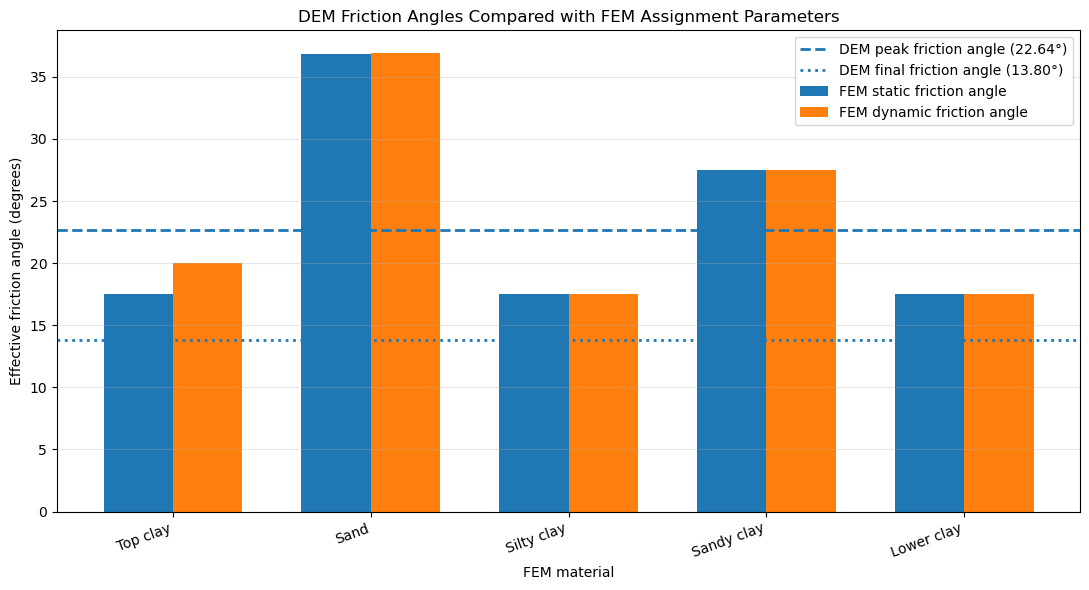

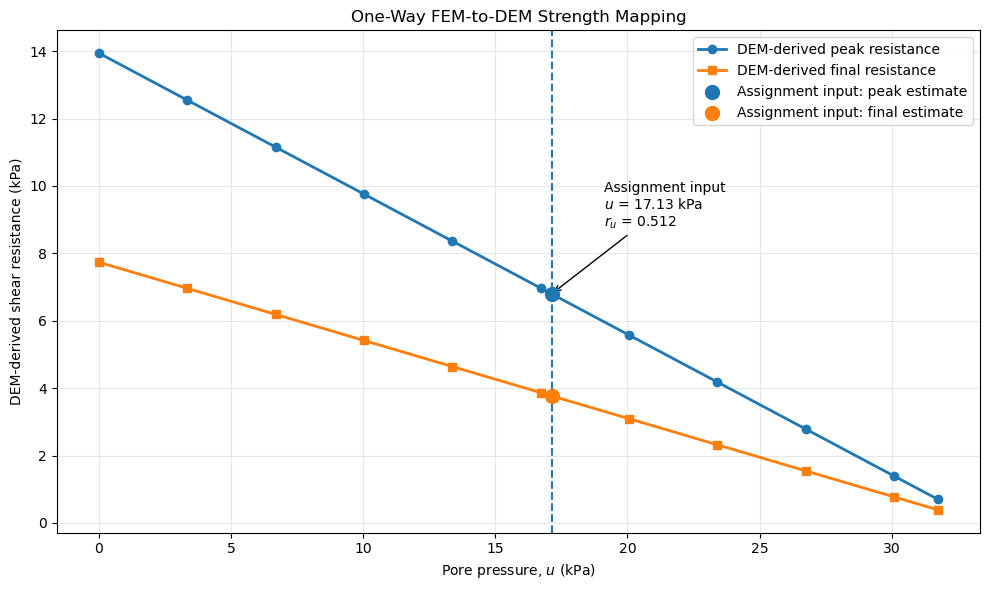

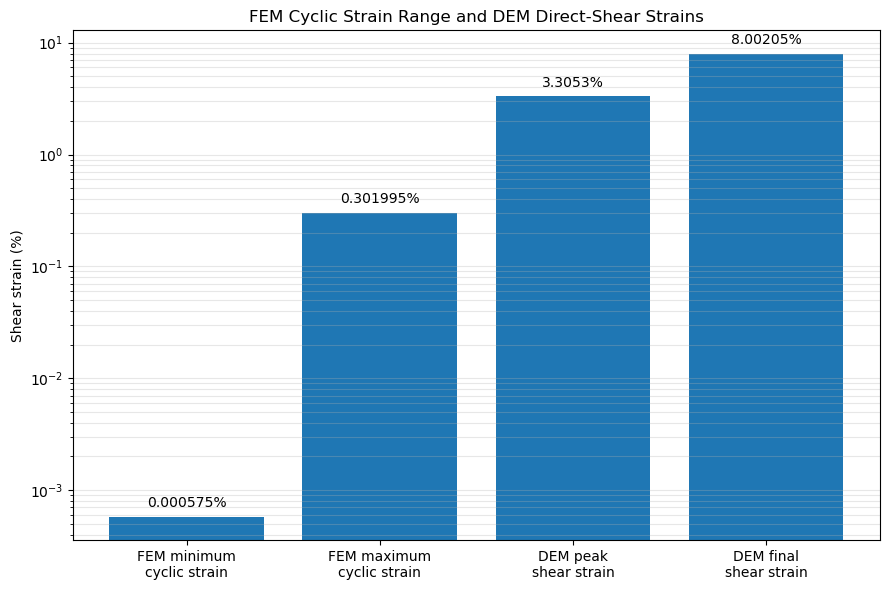

FEM–DEM FIGURE SUMMARY
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\01_friction_angle_comparison.png
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\02_fem_dem_strength_mapping.png
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\03_strain_range_comparison.png

All figures saved successfully : True

INTERPRETATION
Figure 1 compares DEM-derived friction angles with the FEM material parameters.
Figure 2 shows the one-way mapping from assignment pore pressure to DEM-informed peak and final resistance.
Figure 3 shows that the FEM cyclic tests and DEM direct-shear simulation cover different strain ranges.


In [14]:
# ============================================================
# 13. CREATE AND SAVE FEM–DEM COMPARISON FIGURES
# ============================================================

# ------------------------------------------------------------
# Prepare output paths
# ------------------------------------------------------------

friction_angle_figure_path = (
    fem_dem_results_directory
    / "01_friction_angle_comparison.png"
)

strength_mapping_figure_path = (
    fem_dem_results_directory
    / "02_fem_dem_strength_mapping.png"
)

strain_range_figure_path = (
    fem_dem_results_directory
    / "03_strain_range_comparison.png"
)


# ------------------------------------------------------------
# Figure 1:
# DEM friction angles versus FEM material friction angles
# ------------------------------------------------------------

material_names = fem_material_parameters[
    "Material"
].to_numpy()

static_friction_angles = fem_material_parameters[
    "Static friction angle (deg)"
].to_numpy()

dynamic_friction_angles = fem_material_parameters[
    "Dynamic friction angle (deg)"
].to_numpy()

material_positions = np.arange(
    len(material_names)
)

bar_width = 0.35


fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    material_positions - bar_width / 2.0,
    static_friction_angles,
    width=bar_width,
    label="FEM static friction angle",
)

ax.bar(
    material_positions + bar_width / 2.0,
    dynamic_friction_angles,
    width=bar_width,
    label="FEM dynamic friction angle",
)

ax.axhline(
    dem_peak_friction_angle_deg,
    linewidth=2.0,
    linestyle="--",
    label=(
        "DEM peak friction angle "
        f"({dem_peak_friction_angle_deg:.2f}°)"
    ),
)

ax.axhline(
    dem_final_friction_angle_deg,
    linewidth=2.0,
    linestyle=":",
    label=(
        "DEM final friction angle "
        f"({dem_final_friction_angle_deg:.2f}°)"
    ),
)

ax.set_xticks(
    material_positions
)

ax.set_xticklabels(
    material_names,
    rotation=20,
    ha="right",
)

ax.set_xlabel(
    "FEM material"
)

ax.set_ylabel(
    "Effective friction angle (degrees)"
)

ax.set_title(
    "DEM Friction Angles Compared with FEM Assignment Parameters"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

fig.savefig(
    friction_angle_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Figure 2:
# DEM-derived peak and final resistance versus pore pressure
# ------------------------------------------------------------

stored_pore_pressure_kpa = (
    np.asarray(
        pore_pressure_data["pore_pressure"],
        dtype=float,
    )
    / 1000.0
)

stored_peak_resistance_kpa = (
    np.asarray(
        pore_pressure_data["peak_shear_resistance"],
        dtype=float,
    )
    / 1000.0
)

stored_final_resistance_kpa = (
    np.asarray(
        pore_pressure_data["final_shear_resistance"],
        dtype=float,
    )
    / 1000.0
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    stored_pore_pressure_kpa,
    stored_peak_resistance_kpa,
    marker="o",
    linewidth=2.0,
    label="DEM-derived peak resistance",
)

ax.plot(
    stored_pore_pressure_kpa,
    stored_final_resistance_kpa,
    marker="s",
    linewidth=2.0,
    label="DEM-derived final resistance",
)

ax.scatter(
    fem_input_excess_pore_pressure_kpa,
    fem_dem_peak_resistance_kpa,
    s=100,
    zorder=5,
    label="Assignment input: peak estimate",
)

ax.scatter(
    fem_input_excess_pore_pressure_kpa,
    fem_dem_final_resistance_kpa,
    s=100,
    zorder=5,
    label="Assignment input: final estimate",
)

ax.axvline(
    fem_input_excess_pore_pressure_kpa,
    linestyle="--",
    linewidth=1.5,
)

ax.annotate(
    (
        f"Assignment input\n"
        f"$u$ = {fem_input_excess_pore_pressure_kpa:.2f} kPa\n"
        f"$r_u$ = {fem_input_pore_pressure_ratio:.3f}"
    ),
    xy=(
        fem_input_excess_pore_pressure_kpa,
        fem_dem_peak_resistance_kpa,
    ),
    xytext=(
        fem_input_excess_pore_pressure_kpa + 2.0,
        fem_dem_peak_resistance_kpa + 2.0,
    ),
    arrowprops={
        "arrowstyle": "->",
    },
)

ax.set_xlabel(
    "Pore pressure, $u$ (kPa)"
)

ax.set_ylabel(
    "DEM-derived shear resistance (kPa)"
)

ax.set_title(
    "One-Way FEM-to-DEM Strength Mapping"
)

ax.grid(
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

fig.savefig(
    strength_mapping_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Figure 3:
# FEM cyclic strain range versus DEM direct-shear strains
# ------------------------------------------------------------

strain_labels = [
    "FEM minimum\ncyclic strain",
    "FEM maximum\ncyclic strain",
    "DEM peak\nshear strain",
    "DEM final\nshear strain",
]

strain_percent_values = [
    fem_cyclic_minimum_shear_strain_percent,
    fem_cyclic_maximum_shear_strain_percent,
    dem_peak_shear_strain_percent,
    dem_final_shear_strain_percent,
]

strain_positions = np.arange(
    len(strain_labels)
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    strain_positions,
    strain_percent_values,
)

ax.set_yscale(
    "log"
)

ax.set_xticks(
    strain_positions
)

ax.set_xticklabels(
    strain_labels
)

ax.set_ylabel(
    "Shear strain (%)"
)

ax.set_title(
    "FEM Cyclic Strain Range and DEM Direct-Shear Strains"
)

ax.grid(
    axis="y",
    which="both",
    alpha=0.3,
)

for position, value in zip(
    strain_positions,
    strain_percent_values,
):
    ax.text(
        position,
        value * 1.15,
        f"{value:.6g}%",
        ha="center",
        va="bottom",
    )

fig.tight_layout()

fig.savefig(
    strain_range_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Check saved files
# ------------------------------------------------------------

saved_figure_paths = [
    friction_angle_figure_path,
    strength_mapping_figure_path,
    strain_range_figure_path,
]

all_figures_saved = all(
    figure_path.exists()
    for figure_path in saved_figure_paths
)


if not all_figures_saved:
    raise RuntimeError(
        "One or more FEM–DEM comparison figures were not saved."
    )


# ------------------------------------------------------------
# Print figure summary
# ------------------------------------------------------------

print("FEM–DEM FIGURE SUMMARY")
print("=" * 88)

for figure_path in saved_figure_paths:
    print(
        f"SAVED | {figure_path}"
    )

print(
    f"\nAll figures saved successfully : "
    f"{all_figures_saved}"
)


print("\nINTERPRETATION")
print("=" * 88)

print(
    "Figure 1 compares DEM-derived friction angles with the FEM "
    "material parameters."
)

print(
    "Figure 2 shows the one-way mapping from assignment pore pressure "
    "to DEM-informed peak and final resistance."
)

print(
    "Figure 3 shows that the FEM cyclic tests and DEM direct-shear "
    "simulation cover different strain ranges."
)

In [15]:
# ============================================================
# 14. RUN NOTEBOOK 05 ACCEPTANCE CHECKS
# ============================================================

acceptance_checks = []


def record_check(name, condition):
    """
    Store one acceptance check.
    """

    acceptance_checks.append(
        {
            "Check": name,
            "Passed": bool(condition),
        }
    )


# ------------------------------------------------------------
# Input-file and reference checks
# ------------------------------------------------------------

record_check(
    "Notebook 03 result file exists",
    shear_results_path.exists(),
)

record_check(
    "Notebook 04 result file exists",
    pore_pressure_results_path.exists(),
)

record_check(
    "Notebook 03 run is accepted",
    notebook_03_accepted,
)

record_check(
    "Notebook 04 confirms Notebook 03",
    notebook_03_accepted_in_notebook_04,
)

record_check(
    "Notebook 03 and 04 reference stresses match",
    vertical_stress_consistent,
)

record_check(
    "Notebook 03 and 04 peak strengths match",
    peak_stress_consistent,
)

record_check(
    "Notebook 03 and 04 final strengths match",
    final_stress_consistent,
)


# ------------------------------------------------------------
# DEM mechanical checks
# ------------------------------------------------------------

record_check(
    "DEM reference vertical stress is positive",
    dem_target_vertical_stress_kpa > 0.0,
)

record_check(
    "DEM peak resistance is positive",
    dem_peak_shear_stress_kpa > 0.0,
)

record_check(
    "DEM final resistance is positive",
    dem_final_shear_stress_kpa > 0.0,
)

record_check(
    "DEM peak resistance exceeds final resistance",
    dem_peak_shear_stress_kpa > dem_final_shear_stress_kpa,
)

record_check(
    "DEM peak strain occurs before final strain",
    dem_peak_shear_strain < dem_final_shear_strain,
)

record_check(
    "DEM peak friction angle exceeds final angle",
    dem_peak_friction_angle_deg > dem_final_friction_angle_deg,
)


# ------------------------------------------------------------
# FEM assignment input checks
# ------------------------------------------------------------

record_check(
    "FEM domain dimensions are positive",
    (
        fem_domain_width_m > 0.0
        and fem_domain_depth_m > 0.0
    ),
)

record_check(
    "Assignment pore pressure is non-negative",
    fem_dynamic_maximum_excess_pore_pressure_kpa >= 0.0,
)

record_check(
    "Assignment pore-pressure ratio is valid",
    pore_pressure_ratio_valid,
)

record_check(
    "Mapped effective stress remains positive",
    effective_stress_positive,
)


# ------------------------------------------------------------
# FEM-to-DEM link checks
# ------------------------------------------------------------

record_check(
    "Reusable function reproduces effective stress",
    function_effective_stress_matches_previous,
)

record_check(
    "Reusable function reproduces peak resistance",
    function_peak_matches_previous,
)

record_check(
    "Reusable function reproduces final resistance",
    function_final_matches_previous,
)

record_check(
    "Peak scaling reproduces Notebook 04",
    peak_scaling_consistent,
)

record_check(
    "Final scaling reproduces Notebook 04",
    final_scaling_consistent,
)

record_check(
    "Mapped peak resistance exceeds final resistance",
    peak_above_final,
)

record_check(
    "Mapped resistances remain positive",
    resistances_positive,
)

record_check(
    "Strength reduction matches stress reduction",
    reduction_matches_effective_stress,
)


# ------------------------------------------------------------
# Sensitivity-table checks
# ------------------------------------------------------------

record_check(
    "Effective stress decreases with pore pressure",
    effective_stress_monotonic,
)

record_check(
    "Peak resistance decreases with pore pressure",
    peak_resistance_monotonic,
)

record_check(
    "Final resistance decreases with pore pressure",
    final_resistance_monotonic,
)

record_check(
    "Peak resistance exceeds final in every case",
    all_peak_values_above_final,
)


# ------------------------------------------------------------
# Comparison interpretation checks
# ------------------------------------------------------------

record_check(
    "DEM and FEM strain ranges do not overlap",
    not strain_ranges_overlap,
)

record_check(
    "Comparison is not labelled as full validation",
    not full_validation_allowed,
)

record_check(
    "Comparison classification is defined",
    len(comparison_classification.strip()) > 0,
)


# ------------------------------------------------------------
# Figure checks
# ------------------------------------------------------------

record_check(
    "Friction-angle figure exists",
    friction_angle_figure_path.exists(),
)

record_check(
    "Strength-mapping figure exists",
    strength_mapping_figure_path.exists(),
)

record_check(
    "Strain-range figure exists",
    strain_range_figure_path.exists(),
)


# ------------------------------------------------------------
# Create acceptance table
# ------------------------------------------------------------

acceptance_table = pd.DataFrame(
    acceptance_checks
)

number_of_checks = len(
    acceptance_table
)

number_of_passed_checks = int(
    acceptance_table["Passed"].sum()
)

number_of_failed_checks = (
    number_of_checks
    - number_of_passed_checks
)

notebook_05_accepted = (
    number_of_failed_checks == 0
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("NOTEBOOK 05 ACCEPTANCE CHECKS")
print("=" * 92)

for _, row in acceptance_table.iterrows():

    status = (
        "PASS"
        if row["Passed"]
        else "FAIL"
    )

    print(
        f"{status:<6} | {row['Check']}"
    )


print("\nACCEPTANCE SUMMARY")
print("=" * 92)

print(
    f"Total checks                  : "
    f"{number_of_checks}"
)

print(
    f"Passed checks                 : "
    f"{number_of_passed_checks}"
)

print(
    f"Failed checks                 : "
    f"{number_of_failed_checks}"
)

print(
    f"Notebook 05 accepted          : "
    f"{notebook_05_accepted}"
)

print(
    f"Comparison classification     : "
    f"{comparison_classification}"
)


if not notebook_05_accepted:

    failed_checks = acceptance_table.loc[
        ~acceptance_table["Passed"],
        "Check",
    ].tolist()

    failed_check_text = "\n".join(
        f"- {check_name}"
        for check_name in failed_checks
    )

    raise RuntimeError(
        "Notebook 05 acceptance checks failed:\n"
        f"{failed_check_text}"
    )


print("\nFINAL INTERPRETATION")
print("=" * 92)

print(
    "The DEM and FEM results show partial consistency in stress "
    "magnitude and friction-angle range."
)

print(
    "The comparison is not a full validation because geometry, "
    "materials, loading paths and boundary conditions are different."
)

print(
    "The one-way FEM-to-DEM link successfully converts total stress "
    "and pore pressure into DEM-informed peak and final resistance."
)

print(
    "Overall result: NOTEBOOK 05 ACCEPTED"
)

NOTEBOOK 05 ACCEPTANCE CHECKS
PASS   | Notebook 03 result file exists
PASS   | Notebook 04 result file exists
PASS   | Notebook 03 run is accepted
PASS   | Notebook 04 confirms Notebook 03
PASS   | Notebook 03 and 04 reference stresses match
PASS   | Notebook 03 and 04 peak strengths match
PASS   | Notebook 03 and 04 final strengths match
PASS   | DEM reference vertical stress is positive
PASS   | DEM peak resistance is positive
PASS   | DEM final resistance is positive
PASS   | DEM peak resistance exceeds final resistance
PASS   | DEM peak strain occurs before final strain
PASS   | DEM peak friction angle exceeds final angle
PASS   | FEM domain dimensions are positive
PASS   | Assignment pore pressure is non-negative
PASS   | Assignment pore-pressure ratio is valid
PASS   | Mapped effective stress remains positive
PASS   | Reusable function reproduces effective stress
PASS   | Reusable function reproduces peak resistance
PASS   | Reusable function reproduces final resistance
PASS   | 

In [16]:
# ============================================================
# 15. SAVE NOTEBOOK 05 RESULTS
# ============================================================

comparison_csv_path = (
    fem_dem_results_directory
    / "fem_dem_comparison.csv"
)

strength_table_csv_path = (
    fem_dem_results_directory
    / "fem_dem_strength_mapping.csv"
)

acceptance_csv_path = (
    fem_dem_results_directory
    / "notebook_05_acceptance_checks.csv"
)

results_npz_path = (
    fem_dem_results_directory
    / "fem_dem_link_results.npz"
)


# ------------------------------------------------------------
# Save tabular outputs
# ------------------------------------------------------------

comparison_table.to_csv(
    comparison_csv_path,
    index=False,
)

example_fem_dem_table.to_csv(
    strength_table_csv_path,
    index=False,
)

acceptance_table.to_csv(
    acceptance_csv_path,
    index=False,
)


# ------------------------------------------------------------
# Save numerical results
# ------------------------------------------------------------

np.savez(
    results_npz_path,

    # Comparison classification
    comparison_classification=np.array(
        comparison_classification
    ),
    full_validation_allowed=np.array(
        full_validation_allowed
    ),

    # DEM reference values
    dem_reference_vertical_stress_kpa=np.array(
        dem_target_vertical_stress_kpa
    ),
    dem_peak_shear_stress_kpa=np.array(
        dem_peak_shear_stress_kpa
    ),
    dem_final_shear_stress_kpa=np.array(
        dem_final_shear_stress_kpa
    ),
    dem_peak_shear_strain=np.array(
        dem_peak_shear_strain
    ),
    dem_final_shear_strain=np.array(
        dem_final_shear_strain
    ),
    dem_peak_stress_ratio=np.array(
        dem_peak_stress_ratio
    ),
    dem_final_stress_ratio=np.array(
        dem_final_stress_ratio
    ),
    dem_peak_friction_angle_deg=np.array(
        dem_peak_friction_angle_deg
    ),
    dem_final_friction_angle_deg=np.array(
        dem_final_friction_angle_deg
    ),
    dem_effective_cohesion_kpa=np.array(
        dem_effective_cohesion_kpa
    ),

    # Assignment values
    fem_domain_width_m=np.array(
        fem_domain_width_m
    ),
    fem_domain_depth_m=np.array(
        fem_domain_depth_m
    ),
    fem_static_maximum_settlement_m=np.array(
        fem_static_maximum_settlement_m
    ),
    fem_static_maximum_lateral_displacement_m=np.array(
        fem_static_maximum_lateral_displacement_m
    ),
    fem_static_factor_of_safety=np.array(
        fem_static_factor_of_safety
    ),
    fem_dynamic_settlement_m=np.array(
        fem_dynamic_settlement_m
    ),
    fem_dynamic_lateral_displacement_m=np.array(
        fem_dynamic_lateral_displacement_m
    ),
    fem_dynamic_maximum_excess_pore_pressure_kpa=np.array(
        fem_dynamic_maximum_excess_pore_pressure_kpa
    ),

    # FEM-to-DEM mapped state
    mapped_total_vertical_stress_kpa=np.array(
        fem_input_total_vertical_stress_kpa
    ),
    mapped_pore_pressure_kpa=np.array(
        fem_input_excess_pore_pressure_kpa
    ),
    mapped_pore_pressure_ratio=np.array(
        fem_input_pore_pressure_ratio
    ),
    mapped_effective_vertical_stress_kpa=np.array(
        fem_input_effective_vertical_stress_kpa
    ),
    mapped_peak_resistance_kpa=np.array(
        fem_dem_peak_resistance_kpa
    ),
    mapped_final_resistance_kpa=np.array(
        fem_dem_final_resistance_kpa
    ),
    mapped_peak_reduction_percent=np.array(
        peak_resistance_reduction_percent
    ),
    mapped_final_reduction_percent=np.array(
        final_resistance_reduction_percent
    ),

    # Comparison diagnostics
    closest_fem_stress_material=np.array(
        closest_stress_material
    ),
    closest_fem_effective_stress_kpa=np.array(
        closest_fem_effective_stress_kpa
    ),
    closest_stress_absolute_difference_kpa=np.array(
        closest_stress_absolute_difference_kpa
    ),
    closest_stress_relative_difference_percent=np.array(
        closest_stress_relative_difference_percent
    ),
    peak_vs_top_clay_dynamic_difference_deg=np.array(
        peak_vs_top_clay_dynamic_difference_deg
    ),
    final_vs_top_clay_dynamic_difference_deg=np.array(
        final_vs_top_clay_dynamic_difference_deg
    ),
    peak_to_fem_maximum_strain_ratio=np.array(
        peak_to_fem_maximum_ratio
    ),
    final_to_fem_maximum_strain_ratio=np.array(
        final_to_fem_maximum_ratio
    ),
    strain_ranges_overlap=np.array(
        strain_ranges_overlap
    ),

    # Acceptance information
    number_of_acceptance_checks=np.array(
        number_of_checks
    ),
    number_of_passed_checks=np.array(
        number_of_passed_checks
    ),
    number_of_failed_checks=np.array(
        number_of_failed_checks
    ),
    notebook_05_accepted=np.array(
        notebook_05_accepted
    ),
)


# ------------------------------------------------------------
# Verify all saved outputs
# ------------------------------------------------------------

saved_output_paths = [
    comparison_csv_path,
    strength_table_csv_path,
    acceptance_csv_path,
    results_npz_path,
    friction_angle_figure_path,
    strength_mapping_figure_path,
    strain_range_figure_path,
]

all_outputs_saved = all(
    output_path.exists()
    for output_path in saved_output_paths
)


if not all_outputs_saved:
    missing_outputs = [
        str(output_path)
        for output_path in saved_output_paths
        if not output_path.exists()
    ]

    raise RuntimeError(
        "Some Notebook 05 outputs were not saved:\n"
        + "\n".join(missing_outputs)
    )


# ------------------------------------------------------------
# Print final saved-output summary
# ------------------------------------------------------------

print("NOTEBOOK 05 SAVED OUTPUTS")
print("=" * 96)

for output_path in saved_output_paths:
    print(f"SAVED | {output_path}")


print("\nFINAL NOTEBOOK 05 SUMMARY")
print("=" * 96)

print(
    f"Comparison classification      : "
    f"{comparison_classification}"
)

print(
    f"Mapped pore-pressure ratio     : "
    f"{fem_input_pore_pressure_ratio:.6f}"
)

print(
    f"Mapped effective stress        : "
    f"{fem_input_effective_vertical_stress_kpa:.4f} kPa"
)

print(
    f"Mapped peak resistance         : "
    f"{fem_dem_peak_resistance_kpa:.4f} kPa"
)

print(
    f"Mapped final resistance        : "
    f"{fem_dem_final_resistance_kpa:.4f} kPa"
)

print(
    f"Acceptance checks passed       : "
    f"{number_of_passed_checks}/{number_of_checks}"
)

print(
    f"All outputs saved              : "
    f"{all_outputs_saved}"
)

print(
    f"Overall result                 : "
    f"NOTEBOOK 05 ACCEPTED AND SAVED"
)

NOTEBOOK 05 SAVED OUTPUTS
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\fem_dem_comparison.csv
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\fem_dem_strength_mapping.csv
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\notebook_05_acceptance_checks.csv
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\fem_dem_link_results.npz
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\01_friction_angle_comparison.png
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\02_fem_dem_strength_mapping.png
SAVED | C:\Users\duaas\dike_fem_dem_project\results\fem_dem\03_strain_range_comparison.png

FINAL NOTEBOOK 05 SUMMARY
Comparison classification      : Partial consistency check with a one-way FEM-to-DEM demonstration
Mapped pore-pressure ratio     : 0.512458
Mapped effective stress        : 16.2971 kPa
Mapped peak resistance         : 6.7956 kPa
Mapped final resistance        : 3.7707 kPa
Acceptance checks passed       : 35/35
All out

## Final Conclusion

This notebook established a one-way link between the PLAXIS FEM dike analysis and the particle-scale DEM shear model.

The FEM assignment provided the excess pore-pressure condition, while the DEM results provided the relationship between effective vertical stress and mobilised shear resistance. Using an excess pore pressure of 17.13 kPa and the DEM reference total vertical stress of 33.4271 kPa gave:

* pore-pressure ratio, (r_u = 0.5125);
* effective vertical stress, (\sigma'_v = 16.2971\ \text{kPa});
* DEM-informed peak shear resistance of (6.7956\ \text{kPa});
* DEM-informed final shear resistance of (3.7707\ \text{kPa}).

The results show that increasing pore pressure reduces effective stress and therefore reduces the shear resistance available at the mapped FEM stress condition.

The FEM and DEM models use different geometries, material representations, loading paths and boundary conditions. Therefore, the comparison should not be interpreted as a full validation of the PLAXIS model or as a fully coupled FEM–DEM simulation. It is a partial consistency check and a controlled demonstration of how continuum-scale stress and pore-pressure information can be transferred to a particle-scale constitutive response.

All 35 acceptance checks passed, and the numerical tables, figures and restart-compatible output files were saved successfully.

**Overall result: NOTEBOOK 05 ACCEPTED AND SAVED.**
